<h1> Recollect first 100 data for each keyword</h1>

By analyzing the topics from the previously collected videos, we came to an understanding that 250 videos are a lot for the one keyword. Since the You Tube API gives most relevant vidoes first, the last vides are not related to the topic at all sometimes. Because of this we will recollect the data using only first 100 videos. Also, we will change some keywords to make them more specific (e.g. instead of 'rejunivation' 'health rejunevation'). Also we will increase the number videso to 150 for recent years since in those years relevance density might be higher. 

**Let's use the following code:**

In [ ]:
#API keys:
FIRST_API = '***'
SECOND_API = '***'
THIRD_API = '***'
FOURTH_API = '***'

In [111]:
# getting variables ready
from googleapiclient.discovery import build
import pandas as pd
import time

API_KEY = SECOND_API
youtube = build('youtube', 'v3', developerKey = API_KEY)
SEARCH_TERMS = ["biohacking"]
# "longevity", "healthy aging", "biohacking", "health rejuvenation", "anti-aging", "nootropics"

In [113]:
def get_all_videos(query, max_pages=3):
    all_results = []
    next_page_token = None

    for _ in range(max_pages):
        search_response = youtube.search().list(
            q=query,
            part='snippet',
            publishedAfter="2024-01-01T00:00:00Z",
            publishedBefore="2025-01-01T00:00:00Z",
            maxResults=50,
            type='video',
            pageToken=next_page_token
        ).execute()

        all_results.extend(search_response['items'])

        next_page_token = search_response.get('nextPageToken')
        if not next_page_token:
            break

    return all_results

In [ ]:
video_data = []

for term in SEARCH_TERMS:
    search_response = get_all_videos(term)
    
    for item in search_response:
        video_id = item['id']['videoId']
        title = item['snippet']['title']
        description = item['snippet']['description']
        published_at = item['snippet']['publishedAt']
        channel_title = item['snippet']['channelTitle']


        video_response = youtube.videos().list(
            part='statistics,snippet',
            id=video_id
        ).execute()

        stats = video_response['items'][0]['statistics']
        snippet = video_response['items'][0]['snippet']

        # collect the top-level comments
        try:
            comment_response = youtube.commentThreads().list(
                part='snippet',
                videoId=video_id,
                maxResults=5  
            ).execute()

            comments = [c['snippet']['topLevelComment']['snippet']['textDisplay']
                        for c in comment_response.get('items', [])]
            comment_text = " || ".join(comments)

        except:
            comment_text = ""

        

        video_data.append({
            "source": "YouTube",
            "video_id": video_id,
            "video_url": f"https://www.youtube.com/watch?v={video_id}",
            "title": title,
            "description": description,
            "date": published_at,
            "channel": channel_title,
            "comments": comment_text,
            "views": stats.get('viewCount'),
            "likes": stats.get('likeCount'),
            "comments_count": stats.get('commentCount'),
            "keywords": term,
            "country": snippet.get('defaultAudioLanguage', 'unknown')
        })
    
        time.sleep(1)  # Avoid hitting API rate limits


df = pd.DataFrame(video_data)
df.to_csv("first_100_2024_biohacking.csv", index=False)
print("Done! Collected", len(df), "videos.")

<h1> Cleaning + EDA </h1>

We have collected 100 vidoes from each year; however, starting from the year 2019, we increased the number of videos to 150. In below, you can see the data cleaning process and some basic analysis regarding the data. 

<h2> Data cleaning </h2>

In [112]:
import pandas as pd

df_list = []
for i in range(1, 17):
    globals()[f"df_{i}"] = pd.read_csv(f"first_100_20{i+9}.csv")
    df_list.append(globals()[f"df_{i}"])

In [114]:
df = pd.concat(df_list, ignore_index=True)

<h3> Duplicated values and data column</h3>

In [51]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [55]:
df['date_only'] = df['date'].dt.date

In [57]:
df.drop(columns=['date'], inplace=True)

In [59]:
df.rename(columns={"date_only": "date"}, inplace=True)

In [61]:
df.duplicated().sum()

266

In [63]:
df['video_id'].duplicated().sum()

345

In [65]:
df = df.drop_duplicates(keep='first')

In [67]:
df=df.sort_values('date').drop_duplicates(subset='video_id', keep='last')

In [69]:
df.duplicated().sum()

0

In [71]:
df['video_id'].duplicated().sum()

0

<h3>Null values</h3>

In [75]:
df.isnull().sum()

source               0
video_id             0
video_url            0
title                0
description       1058
channel              0
comments          5718
views                7
likes              366
comments_count     591
keywords             0
country              0
date                 0
dtype: int64

In [85]:
df['description'] = df['description'].fillna('')
df['comments']=df['comments'].fillna('')
df['comments_count']=df['comments_count'].fillna(0)
df = df[~df['views'].isnull()] 

In [87]:
df.isnull().sum()

source              0
video_id            0
video_url           0
title               0
description         0
channel             0
comments            0
views               0
likes             366
comments_count      0
keywords            0
country             0
date                0
dtype: int64

Likes are null in some videos because creator didn't want it to show. So let's create another column called "likes_missing" to flag those videos and change null values to zero. 

In [90]:
df['likes_missing'] = df['likes'].isnull()

In [96]:
df['likes'] = df['likes'].fillna(0)

In [98]:
df.isnull().sum()

source            0
video_id          0
video_url         0
title             0
description       0
channel           0
comments          0
views             0
likes             0
comments_count    0
keywords          0
country           0
date              0
likes_missing     0
dtype: int64

In [102]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [106]:
df.dtypes

source                    object
video_id                  object
video_url                 object
title                     object
description               object
channel                   object
comments                  object
views                    float64
likes                    float64
comments_count           float64
keywords                  object
country                   object
date              datetime64[ns]
likes_missing               bool
dtype: object

<h3> Basic analysis </h3>

In [110]:
df['keywords'].value_counts() # number of keywords in the dataset

keywords
healthy aging          1920
longevity              1909
biohacking             1896
health rejuvenation    1893
nootropics             1887
anti-aging             1843
Name: count, dtype: int64

**Number of videos for each year**

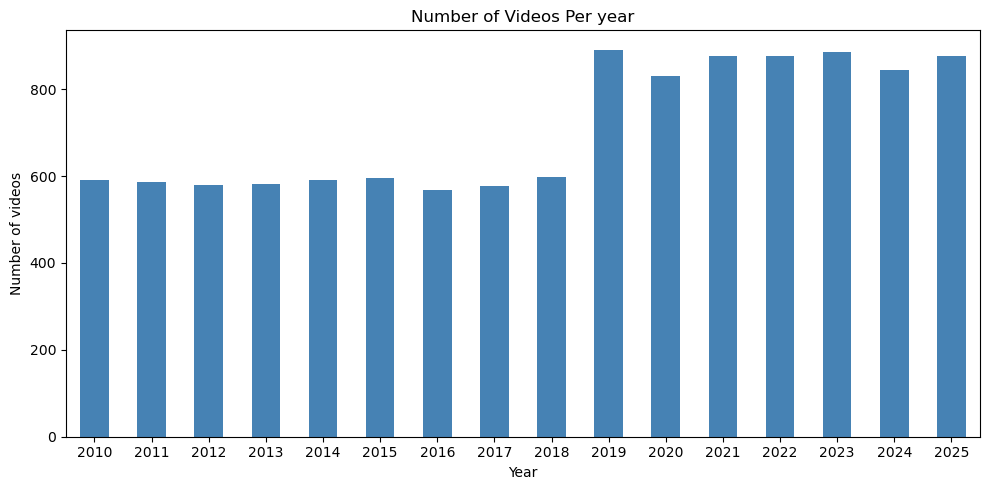

In [113]:
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['year'] = df['date'].dt.year

yearly_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='bar', color='steelblue')

plt.title('Number of Videos Per year')
plt.xlabel('Year')
plt.ylabel('Number of videos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

As you can see, number of videos are higher starting from 2019, it is perfectly intentional since in recent years, there might be more related vidoes to our research

<h4>Basic engagement analysis</h4>

Let's create the engagement column for each video which represents the how the users are engaged. It will be the sum of likes and comment counts

In [121]:
df['engagement']=df['likes'] + df['comments_count']

In [123]:
df.groupby('keywords')['engagement'].mean().sort_values(ascending=False)

keywords
anti-aging             7334.956050
longevity              2971.390781
health rejuvenation    2359.633386
biohacking             1635.926160
healthy aging           786.830729
nootropics              564.731849
Name: engagement, dtype: float64

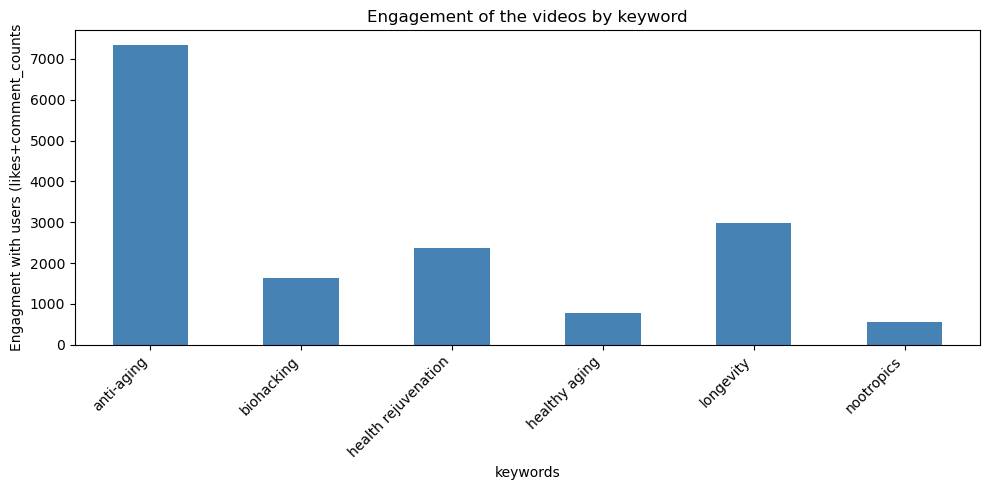

In [125]:
engagement_by_keyword = df.groupby('keywords')['engagement'].mean()

plt.figure(figsize=(10, 5))

engagement_by_keyword.plot(kind='bar', color='steelblue')

plt.title('Engagement of the videos by keyword')
plt.xlabel('keywords')
plt.ylabel('Engagment with users (likes+comment_counts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Engagement rate**

Let's create the column called 'engagement_rate'. This columsn will represent the percentage of the people who have actively engaged with the video. This can give give us the insights such as which topics (keywords) have created more discussions. The rate will be engagement/views

A video with 10,000 views and 200 total interactions (2%) may be more engaging than one with 1M views and 5,000 interactions (0.5%).

In [129]:
df['engagement_rate'] = df['engagement'] / df['views']
df.loc[df['views'] == 0, 'engagement_rate'] = 0

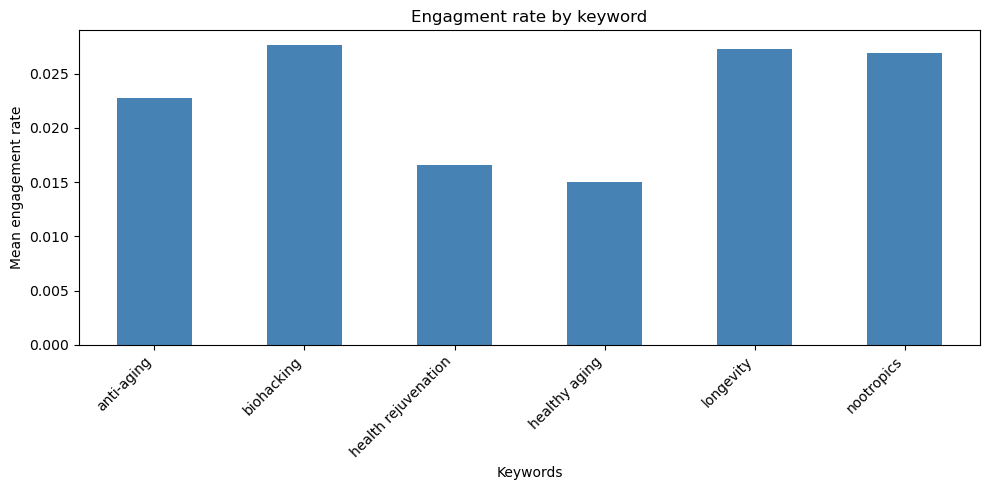

In [131]:
import matplotlib.pyplot as plt

engagement_rate_keyword = df.groupby('keywords')['engagement_rate'].mean()

plt.figure(figsize=(10, 5))

engagement_rate_keyword.plot(kind='bar', color='steelblue')
plt.title('Engagment rate by keyword')
plt.xlabel('Keywords')
plt.ylabel('Mean engagement rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The engagement rate of the "biohacking", "longevity", "nootropics" are higher compared to the anti-aging. However, engagment value of the anti-aging was higher. But with the help of the engagement rate, we will know how many people are engaged with the vidoe out of people who really watched that video. In another words, biohacking, longevity and bootropics created more discussion among the people who watched vidoes related to those topics. 

**Engagment rate over time**

<Axes: xlabel='year'>

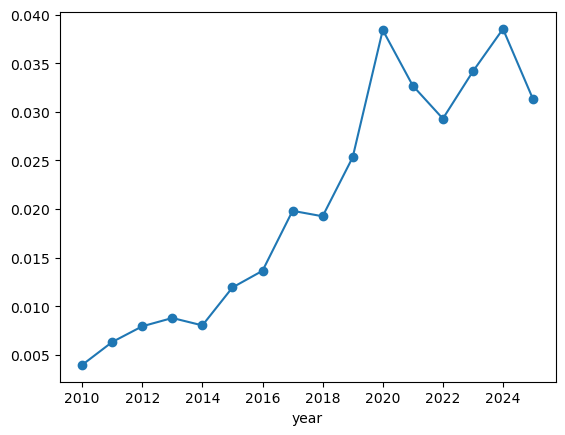

In [137]:
df.groupby('year')['engagement_rate'].mean().plot(kind='line', marker='o')


let's save the data for the later use

In [142]:
df.to_csv("recollect_100_clean.csv", index=False)

<h1>Bertopic analysis</h1>

**Prepare the data**

In [146]:
df['text'] = df['title'] + ' ' + df['description']

<h2>MPnet</h2>

In [173]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

model = SentenceTransformer("paraphrase-mpnet-base-v2") #more nuanced model 

# Custom preprocessing with vectorizer
vectorizer_model = CountVectorizer(
    stop_words="english",  
    ngram_range=(1, 2),    
    max_df=0.85,           
    min_df=2,              
    max_features=3000  
)

# Creating BERTopic model
topic_model = BERTopic(
    embedding_model=model,
    vectorizer_model=vectorizer_model,
    nr_topics="auto",
    top_n_words=10,       
    calculate_probabilities=True,
    min_topic_size=20 #reduces overly small clusters
)

In [175]:
topics, probs = topic_model.fit_transform(df['text'].fillna("").tolist())

In [177]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3612,-1_longevity_nootropics_aging_healthy,"[longevity, nootropics, aging, healthy, health...","[Healthy heart, healthy aging #Fitspace24 #Her..."
1,0,5102,0_aging_anti_anti aging_rejuvenation,"[aging, anti, anti aging, rejuvenation, health...","[Healthy Aging: Watch Your Back , AlfaOmega An..."
2,1,1648,1_biohacking_biohacker_biohack_dave,"[biohacking, biohacker, biohack, dave, dave as...",[What Are The Top Biohacking Wearables? #short...
3,2,827,2_nootropics_nootropic_brain_stack,"[nootropics, nootropic, brain, stack, nootropi...",[Everyone is taking nootropics Our products/So...
4,3,68,3_klaus_workout_denmark_2011,"[klaus, workout, denmark, 2011, season, super,...",[MUTANT athlete KLAUS RIIS will be at FIBO 201...
5,4,62,4_dens_lower_arduino_nootropicdesign,"[dens, lower, arduino, nootropicdesign, nootro...",[Arduino Worm See https://nootropicdesign.com/...
6,5,29,5_diy_bio_diy bio_co2,"[diy, bio, diy bio, co2, outside, reducing, pr...","[DIY Bio-Pellets Reactor , DIY bio-pellets rea..."


In [179]:
df['topic']=topics

In [183]:
df.to_csv("mpnet_paraphrase_data.csv", index=False)

In [185]:
topic_model.get_topic_info().to_csv("mpnet_paraphrase_topics.csv", index=False)

<h3> Analaysis of the MPnet</h3>

Let's analyze the topics that we got from the MPnet sentence transformer. As you can see we have gotten the 6 topics and one noisy data. If you look at the representation keywords, then we can see that topic 3, 4 and 5 seem like irrelevant. To make sure, let's give the relevance score for each of them, and check mannually 

In [1]:
import pandas as pd

tpp = pd.read_csv("mpnet_paraphrase_topics.csv")
df = pd.read_csv("mpnet_paraphrase_data.csv", keep_default_na=False)

In [3]:
#function to check if the video is related or unrelated

def is_video_related(text, keywords):
    text = str(text).lower()
    return any(kw in text for kw in keywords)

In [5]:
def check_relevance_ratio(df, topic_id, keywords):
    df_topic = df[df['topic']==topic_id]
    relevant_count = df_topic['text'].apply(lambda x: is_video_related(x, keywords)).sum()
    return relevant_count/len(df_topic)

keywords = ["longevity", "healthy aging", "biohacking", "rejuvenation", "anti-aging", "nootropics", "health"]

In [7]:
tpp['relevance_ratio'] = tpp['Topic'].apply(lambda t: check_relevance_ratio(df, t, keywords)) 

In [9]:
tpp

,Topic,Count,Name,Representation,Representative_Docs,relevance_ratio
0,-1,3612,-1_longevity_nootropics_aging_healthy,"['longevity', 'nootropics', 'aging', 'healthy'...","['Healthy heart, healthy aging #Fitspace24 #He...",0.854097
1,0,5102,0_aging_anti_anti aging_rejuvenation,"['aging', 'anti', 'anti aging', 'rejuvenation'...","['Healthy Aging: Watch Your Back ', 'AlfaOmega...",0.877107
2,1,1648,1_biohacking_biohacker_biohack_dave,"['biohacking', 'biohacker', 'biohack', 'dave',...",['What Are The Top Biohacking Wearables? #shor...,0.827063
3,2,827,2_nootropics_nootropic_brain_stack,"['nootropics', 'nootropic', 'brain', 'stack', ...",['Everyone is taking nootropics Our products/S...,0.714631
4,3,68,3_klaus_workout_denmark_2011,"['klaus', 'workout', 'denmark', '2011', 'seaso...",['MUTANT athlete KLAUS RIIS will be at FIBO 20...,0.000000
5,4,62,4_dens_lower_arduino_nootropicdesign,"['dens', 'lower', 'arduino', 'nootropicdesign'...",['Arduino Worm See https://nootropicdesign.com...,0.241935
6,5,29,5_diy_bio_diy bio_co2,"['diy', 'bio', 'diy bio', 'co2', 'outside', 'r...","['DIY Bio-Pellets Reactor ', 'DIY bio-pellets ...",0.034483


As you can see, relevance ratio of the last 3 toics are very small compared to the first 4. However, before deleting them, let's check first 5 videos from each topic mannually

<h4>Manual checking</h4>

In [11]:
df[df['topic']==3].head(5)

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic
50,YouTube,dljjppt2tJY,https://www.youtube.com/watch?v=dljjppt2tJY,Klaus Riis doing splits 2010,February 2010....Klaus doing splits while prac...,Klaus Myren Riis Viking Fitness Coach & Biohac...,WOW!! AWESOME!\n || haha ja skal jeg nok Mikke...,4296.0,7.0,3.0,biohacking,unknown,2010-02-02,False,2010,10.0,0.002328,Klaus Riis doing splits 2010 February 2010.......,3
55,YouTube,cRvG2NM0tFU,https://www.youtube.com/watch?v=cRvG2NM0tFU,Klaus Riis Posing seminar,Fisrt Posing Seminar held by Klaus Riis at Key...,Klaus Myren Riis Viking Fitness Coach & Biohac...,ham i army bukserne er da lidt af en frækkert ...,2440.0,3.0,1.0,biohacking,unknown,2010-02-08,False,2010,4.0,0.001639,Klaus Riis Posing seminar Fisrt Posing Seminar...,3
90,YouTube,YUGyUbbnjkc,https://www.youtube.com/watch?v=YUGyUbbnjkc,Klaus Riis Workout shoot 2010 sponsored by LOADED,Klaus Riis Workout shoot 2010 sponsored by LOA...,Klaus Myren Riis Viking Fitness Coach & Biohac...,"Jeg ved ikk meget om dig og din baggrund, men ...",2272.0,3.0,1.0,biohacking,unknown,2010-03-04,False,2010,4.0,0.001761,Klaus Riis Workout shoot 2010 sponsored by LOA...,3
267,YouTube,07b2RtHLClQ,https://www.youtube.com/watch?v=07b2RtHLClQ,TEASER - Training series with Klaus Riis,Teaser for Upcoming Training series featuring ...,Klaus Myren Riis Viking Fitness Coach & Biohac...,det ser sku godt ud!,2749.0,5.0,1.0,biohacking,unknown,2010-07-14,False,2010,6.0,0.002183,TEASER - Training series with Klaus Riis Tease...,3
277,YouTube,TFGoky4UB5c,https://www.youtube.com/watch?v=TFGoky4UB5c,Training series with Klaus Riis #2,Legs and Strongman stuff... Training series fe...,Klaus Myren Riis Viking Fitness Coach & Biohac...,klaus mate i would love to see you compete at ...,3323.0,8.0,1.0,biohacking,unknown,2010-07-16,False,2010,9.0,0.002708,Training series with Klaus Riis #2 Legs and St...,3


This topic has the videos of the training session of the bodybuilder called Klaus Riis. Deeply unrelated to our topic. let's delete it

In [13]:
df[df['topic']==4].head(5)

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic
136,YouTube,1sdiTyklB8Y,https://www.youtube.com/watch?v=1sdiTyklB8Y,Ten Second War Trailer,Ten Second War is an indie video game that I'v...,AlmostMatt,Holy--------<br>the time limit idea is really ...,12010.0,24.0,5.0,biohacking,unknown,2010-04-10,False,2010,29.0,0.002415,Ten Second War Trailer Ten Second War is an in...,4
226,YouTube,cgnCIQPgPAs,https://www.youtube.com/watch?v=cgnCIQPgPAs,12-string Guitar: With My Swag All On My Shoul...,This is one of the songs of The Seekers that d...,threelegsoman,@ErunorLRugby Sounds like an interesting parody.,1968.0,15.0,1.0,biohacking,unknown,2010-06-15,False,2010,16.0,0.008130,12-string Guitar: With My Swag All On My Shoul...,4
373,YouTube,fOUa_jcHIkE,https://www.youtube.com/watch?v=fOUa_jcHIkE,Space Invaders + Pong,"Hackvision is the tiny, hackable, Arduino-base...",nootropic design,How can I buy it? How much is it? || :),39415.0,35.0,5.0,nootropics,unknown,2010-09-18,False,2010,40.0,0.001015,"Space Invaders + Pong Hackvision is the tiny, ...",4
377,YouTube,dFdk9YMBLeQ,https://www.youtube.com/watch?v=dFdk9YMBLeQ,Arduino Mood Lamp Made from LEDs and Glass Vials,"For all the project details and code, visit ht...",nootropic design,"Bro, i need to learn Radio astronomy. I alre...",2446.0,5.0,3.0,nootropics,unknown,2010-09-20,False,2010,8.0,0.003271,Arduino Mood Lamp Made from LEDs and Glass Via...,4
378,YouTube,OC05Hnyc1bo,https://www.youtube.com/watch?v=OC05Hnyc1bo,Arduino-Controlled Lock,Read the project details at https://nootropicd...,nootropic design,,2778.0,4.0,0.0,nootropics,unknown,2010-09-20,False,2010,4.0,0.001440,Arduino-Controlled Lock Read the project detai...,4


Topic 4 also contains unrelated vidoes a lot. It is about ardiuno mostly.

In [15]:
df[df['topic']==5].head(5)

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic
149,YouTube,dTz_b_mitlc,https://www.youtube.com/watch?v=dTz_b_mitlc,DIY Bio-Pellets Reactor,,Him .Cheng,,1024.0,0.0,0.0,biohacking,unknown,2010-04-23,False,2010,0.0,0.000000,DIY Bio-Pellets Reactor,5
196,YouTube,iU36n7C-3ik,https://www.youtube.com/watch?v=iU36n7C-3ik,Rickets Reef: DIY BioPellet Box,Quick vid showing a little box I made to hold ...,Rickets Reef,All you need to do is get a small screwdriver ...,12348.0,10.0,4.0,biohacking,unknown,2010-05-23,False,2010,14.0,0.001134,Rickets Reef: DIY BioPellet Box Quick vid show...,5
275,YouTube,Gqd1aVjeT7c,https://www.youtube.com/watch?v=Gqd1aVjeT7c,NP Reducing Biopellets - Filtr DIY Bio pellets,NP Reducing Biopellets - Filtr DIY.,Sebastek74,I am sure you&#39;ll learn how to make it if y...,1722.0,1.0,1.0,biohacking,unknown,2010-07-16,False,2010,2.0,0.001161,NP Reducing Biopellets - Filtr DIY Bio pellets...,5
338,YouTube,36fWx3i5L4o,https://www.youtube.com/watch?v=36fWx3i5L4o,DIY Protein Skimmer by Sebastek - Panelowy Odp...,DIY Protein Skimmer by Sebastek - Panelowy Odp...,Sebastek74,seriously?... ANOTHER without narration!!!!......,7413.0,2.0,1.0,biohacking,unknown,2010-08-29,False,2010,3.0,0.000405,DIY Protein Skimmer by Sebastek - Panelowy Odp...,5
365,YouTube,RN4pMCi6_kg,https://www.youtube.com/watch?v=RN4pMCi6_kg,DiY Bio-Pellets reactor,"Cocacola lahev 2l 0,- Starší čerpadlo 1200 l/h...",S4Sulda,So how did that work out for you? Still in use...,5055.0,6.0,2.0,biohacking,unknown,2010-09-12,False,2010,8.0,0.001583,"DiY Bio-Pellets reactor Cocacola lahev 2l 0,- ...",5


This topic also contains the videos which are mostly unrelated.

After checking the topics 3, 4 and 5, I have come to the conclusion that it is safe to delete them from our dataset. 

In [17]:
df = df[~df['topic'].isin([3, 4, 5])]
tpp = tpp[~tpp['Topic'].isin([3, 4, 5])]

In [19]:
tpp

,Topic,Count,Name,Representation,Representative_Docs,relevance_ratio
0,-1,3612,-1_longevity_nootropics_aging_healthy,"['longevity', 'nootropics', 'aging', 'healthy'...","['Healthy heart, healthy aging #Fitspace24 #He...",0.854097
1,0,5102,0_aging_anti_anti aging_rejuvenation,"['aging', 'anti', 'anti aging', 'rejuvenation'...","['Healthy Aging: Watch Your Back ', 'AlfaOmega...",0.877107
2,1,1648,1_biohacking_biohacker_biohack_dave,"['biohacking', 'biohacker', 'biohack', 'dave',...",['What Are The Top Biohacking Wearables? #shor...,0.827063
3,2,827,2_nootropics_nootropic_brain_stack,"['nootropics', 'nootropic', 'brain', 'stack', ...",['Everyone is taking nootropics Our products/S...,0.714631


<h3>Subtopics</h3>

I will use following code to find the subtopics for each topic that we have here

In [21]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

model = SentenceTransformer("paraphrase-mpnet-base-v2") #more nuanced model 

# Custom preprocessing with vectorizer
vectorizer_model = CountVectorizer(
    stop_words="english",  
    ngram_range=(1, 2),    
    max_df=0.85,           
    min_df=2,              
    max_features=3000  
)


subtopic_models = {}
subtopic_infos = {}
all_subtopics = []
all_indices = []


for topic_id in tpp['Topic']: 
    
    mask = df['topic'] == topic_id
    docs_in_topic = df[mask]['text'].tolist()
    indices = df[mask].index.tolist()
    
    

    sub_model = BERTopic(
            embedding_model=model,
            vectorizer_model=vectorizer_model,
            nr_topics="auto",
            top_n_words=10,       
            calculate_probabilities=True,
            min_topic_size=15 
        )
    sub_topics, _ = sub_model.fit_transform(docs_in_topic)
    
    all_subtopics.extend(sub_topics)
    all_indices.extend(indices)

    subtopic_models[topic_id] = sub_model
    subtopic_infos[topic_id] = sub_model.get_topic_info()

In [40]:
subtopic_infos[2]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5,-1_social_social nootropics_self_https,"[social, social nootropics, self, https, media...",[Boost Energy and Focus: Affordable Nootropic ...
1,0,246,0_brain_boost_coffee_memory,"[brain, boost, coffee, memory, focus, cognitiv...",[So much more than just coffee! #coffee #savvy...
2,1,122,1_gen_nootropic stack_https www_product,"[gen, nootropic stack, https www, product, pro...",[DEBUNKING: Nootropics are a SCAM Our products...
3,2,104,2_review_best_update_best nootropics,"[review, best, update, best nootropics, talk, ...",[Adrafinil Review - Best Nootropic Adrafinil R...
4,3,81,3_drugs_smart_smart drugs_students,"[drugs, smart, smart drugs, students, college,...","[Smart Drugs , Smart Drugs , Smart Drugs ]"
5,4,46,4_piracetam_phenylpiracetam_choline_review,"[piracetam, phenylpiracetam, choline, review, ...",[Piracetam Choline Review &amp; Mind Boost Pir...
6,5,40,5_benefits_including_nootropic benefits_video ll,"[benefits, including, nootropic benefits, vide...",[Glutathione In this video you'll discover the...
7,6,30,6_fuel_edge_energy_elite,"[fuel, edge, energy, elite, unboxing, mind, sh...",[Korvyx - Fuel Your Force #brainupgrade #nootr...
8,7,29,7_alpha_alpha brain_onnit_brain,"[alpha, alpha brain, onnit, brain, rogan, joe ...",[Alpha Brain Review Real User Experience-Onnit...
9,8,28,8_noopept_2014_april_21,"[noopept, 2014, april, 21, 22, med, 23, 11, pe...","[Dag 11, Nootropics (Noopept + Neurostim), 1 a..."


In [56]:
df.loc[all_indices, 'subtopic'] = all_subtopics

In [62]:
#let's save our data
df.to_csv("Subtopics-Mpnet/data.csv", index=False)
for i in range(-1, 3):
    subtopic_infos[i].to_csv(f"Subtopics-Mpnet/subtopic_{i}.csv", index=False)
    subtopic_models[i].save(f"Subtopics-Mpnet/subtopic_model_{i}")

2025-08-09 14:53:35,809 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2025-08-09 14:53:39,188 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2025-08-09 14:53:59,693 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2025-08-09 14:54:04,874 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the mo

<h4>Analysis of subtopics of topic -1</h4>

In [82]:
import pandas as pd

df = pd.read_csv("Subtopics-Mpnet/data.csv", keep_default_na=False)
tpp_min_1 = pd.read_csv("Subtopics-Mpnet/subtopic_-1.csv")
tpp_min_1

,Topic,Count,Name,Representation,Representative_Docs
0,-1,96,-1_aging_beverly_hills_beverly hills,"['aging', 'beverly', 'hills', 'beverly hills',...",['What is your counsel? New videos DAILY: http...
1,0,1863,0_longevity_aging_healthy_healthy aging,"['longevity', 'aging', 'healthy', 'healthy agi...","[""HEALTHY AGING MONTH with Dr. Contessa Metcal..."
2,1,914,1_nootropics_nootropic_brain_best,"['nootropics', 'nootropic', 'brain', 'best', '...",['Best nootropics for 2023 DHA Best nootropics...
3,2,473,2_rejuvenation_skin_skin rejuvenation_facial,"['rejuvenation', 'skin', 'skin rejuvenation', ...","['HiFo Skin Rejuvenation Oxygeneo system ', 'L..."
4,3,68,3_rejuvenation_health rejuvenation_yoga_health,"['rejuvenation', 'health rejuvenation', 'yoga'...",['Miraculous Blessings from the Angelic Forces...
5,4,68,4_biohacking_la_biohacker_le,"['biohacking', 'la', 'biohacker', 'le', 'fatig...",['Caso farmacéuticos #medicinabienestar #theDN...
6,5,33,5_smart drugs_smart_drugs_le,"['smart drugs', 'smart', 'drugs', 'le', 'di', ...",['Smart drugs - le nuove droghe In Italia sta ...
7,6,23,6_fitness_aging fitness_workout_student,"['fitness', 'aging fitness', 'workout', 'stude...",['Healthy Aging Fitness: December 2021 In this...
8,7,20,7_на_за_видео_facemassage,"['на', 'за', 'видео', 'facemassage', 'title', ...",['ЭФФЕКТИВНЫЙ массаж для красоты лица! #массаж...
9,8,19,8_silk_anti_anti aging_light,"['silk', 'anti', 'anti aging', 'light', 'aging...","[""Silk&#39;n FaceFX Anti-Aging/Skin Rejuvenati..."


**Let's create the pipeline which will give our subtopics the relavence score**

In [84]:
def is_video_related(text, keywords):
    text = str(text).lower()
    return any(kw in text for kw in keywords)

def check_relevance_ratio(df, topic_id, subtopic_id, keywords):
    df_topic = df[(df['topic']==topic_id) & (df['subtopic']==subtopic_id)]
    relevant_count = df_topic['text'].apply(lambda x: is_video_related(x, keywords)).sum()
    return relevant_count/len(df_topic)

keywords = ["longevity", "healthy aging", "biohacking", "rejuvenation", "anti-aging", "nootropics", "health"]

In [86]:
tpp_min_1['relevance_ratio'] = tpp_min_1['Topic'].apply(lambda t: check_relevance_ratio(df,-1, t, keywords))

In [88]:
tpp_min_1

,Topic,Count,Name,Representation,Representative_Docs,relevance_ratio
0,-1,96,-1_aging_beverly_hills_beverly hills,"['aging', 'beverly', 'hills', 'beverly hills',...",['What is your counsel? New videos DAILY: http...,0.593750
1,0,1863,0_longevity_aging_healthy_healthy aging,"['longevity', 'aging', 'healthy', 'healthy agi...","[""HEALTHY AGING MONTH with Dr. Contessa Metcal...",0.929683
2,1,914,1_nootropics_nootropic_brain_best,"['nootropics', 'nootropic', 'brain', 'best', '...",['Best nootropics for 2023 DHA Best nootropics...,0.748359
3,2,473,2_rejuvenation_skin_skin rejuvenation_facial,"['rejuvenation', 'skin', 'skin rejuvenation', ...","['HiFo Skin Rejuvenation Oxygeneo system ', 'L...",0.902748
4,3,68,3_rejuvenation_health rejuvenation_yoga_health,"['rejuvenation', 'health rejuvenation', 'yoga'...",['Miraculous Blessings from the Angelic Forces...,0.926471
5,4,68,4_biohacking_la_biohacker_le,"['biohacking', 'la', 'biohacker', 'le', 'fatig...",['Caso farmacéuticos #medicinabienestar #theDN...,0.779412
6,5,33,5_smart drugs_smart_drugs_le,"['smart drugs', 'smart', 'drugs', 'le', 'di', ...",['Smart drugs - le nuove droghe In Italia sta ...,0.030303
7,6,23,6_fitness_aging fitness_workout_student,"['fitness', 'aging fitness', 'workout', 'stude...",['Healthy Aging Fitness: December 2021 In this...,0.739130
8,7,20,7_на_за_видео_facemassage,"['на', 'за', 'видео', 'facemassage', 'title', ...",['ЭФФЕКТИВНЫЙ массаж для красоты лица! #массаж...,0.000000
9,8,19,8_silk_anti_anti aging_light,"['silk', 'anti', 'anti aging', 'light', 'aging...","[""Silk&#39;n FaceFX Anti-Aging/Skin Rejuvenati...",0.842105


Let's look at the topics number 5 and 7 since their relevance score is very low

In [92]:
#Let's check the topic 5
df[(df['topic']==-1) & (df['subtopic']==5)].head(5)

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
100,YouTube,jw6LFYVwZBE,https://www.youtube.com/watch?v=jw6LFYVwZBE,Smart drugs a Riccione,"Lo Spice cambia nel nome, ma non nella sostanz...",SanPatrignano,Ma se il benzinaio vende la benzina e uno se l...,4203.0,6.0,8.0,nootropics,unknown,2010-03-12,False,2010,14.0,0.003331,Smart drugs a Riccione Lo Spice cambia nel nom...,-1,5.0
187,YouTube,q879CC1w6Ic,https://www.youtube.com/watch?v=q879CC1w6Ic,Melkizionel Shir yedidot - ( Celtic Jew Cultur...,Jewish -Alsace / Elsàss Tribe of Dan / Dafydd ...,Dafydd Melkizionel,,312.0,4.0,0.0,biohacking,en-GB,2010-05-20,False,2010,4.0,0.012821,Melkizionel Shir yedidot - ( Celtic Jew Cultur...,-1,5.0
205,YouTube,hOp0JEowFTo,https://www.youtube.com/watch?v=hOp0JEowFTo,Smart drugs - gli effetti,smart drugs - ecco cosa succede quando si assu...,SanPatrignano,Video totalmente antiscientifico || I nootropi...,4962.0,7.0,6.0,nootropics,unknown,2010-06-04,False,2010,13.0,0.002620,Smart drugs - gli effetti smart drugs - ecco c...,-1,5.0
214,YouTube,tWOKOlv0_xk,https://www.youtube.com/watch?v=tWOKOlv0_xk,Giovanni Serpelloni - smart drugs,Giovanni Serpelloni - smart drugs.,SanPatrignano,Idiota con il proibizionismo è peggiorato tutt...,261.0,0.0,1.0,nootropics,unknown,2010-06-11,False,2010,1.0,0.003831,Giovanni Serpelloni - smart drugs Giovanni Ser...,-1,5.0
258,YouTube,DZEHqWNniuQ,https://www.youtube.com/watch?v=DZEHqWNniuQ,Ans - Smart Drugs Taster,OWN026 Ans Run Like Mad EP Restless Ans presen...,Owntempo,,1215.0,5.0,0.0,nootropics,unknown,2010-07-13,False,2010,5.0,0.004115,Ans - Smart Drugs Taster OWN026 Ans Run Like M...,-1,5.0


The videos in subtopic of the topic -1 are mostly in Spanish. Since we are only focusing on the songs with English content, it's save to delete them. 

In [99]:
#Let's check the topic 7
df[(df['topic']==-1) & (df['subtopic']==7)].head(5)

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
1302,YouTube,CRe9QdL3648,https://www.youtube.com/watch?v=CRe9QdL3648,Биохакеры «взламывают» ДНК в домашних условиях,Они уже научились заряжать плееры от кухонного...,День Х,если его реактор потребляет больше чем произво...,8360.0,81.0,6.0,biohacking,unknown,2012-06-06,False,2012,87.0,0.010407,Биохакеры «взламывают» ДНК в домашних условиях...,-1,7.0
1502,YouTube,Y3Rx_vyRirY,https://www.youtube.com/watch?v=Y3Rx_vyRirY,Клиническая фармакология ноотропов неврология...,,Медицинский вестник,Все препараты пустышки. || Никто не отменял Фа...,8947.0,65.0,6.0,nootropics,unknown,2012-10-28,False,2012,71.0,0.007936,Клиническая фармакология ноотропов неврология...,-1,7.0
2171,YouTube,mqC5SjlZipY,https://www.youtube.com/watch?v=mqC5SjlZipY,НООТРОП - для работы мозга!,,RIAPanda,а как зовут девушку?,4047.0,12.0,1.0,nootropics,unknown,2013-12-26,False,2013,13.0,0.003212,НООТРОП - для работы мозга!,-1,7.0
2498,YouTube,T507ClGfD44,https://www.youtube.com/watch?v=T507ClGfD44,बायोहैकिंग,हैकिंग सुनते ही लगता है कि कंप्यूटर हैकरों की ...,DW हिन्दी,,407.0,6.0,0.0,biohacking,unknown,2014-07-16,False,2014,6.0,0.014742,बायोहैकिंग हैकिंग सुनते ही लगता है कि कंप्यूटर...,-1,7.0
9768,YouTube,juz_sfpDHmg,https://www.youtube.com/watch?v=juz_sfpDHmg,КОЖА ПОД ГЛАЗАМИ БЕЗ ПЯТЕН И МОРЩИН,Пантенол и Аевит для лица. Аптечные средства д...,Beautiful illusion,Не кому заставляет делать😅 || Внешний вид не о...,991348.0,26678.0,260.0,health rejuvenation,ru,2024-06-14,False,2024,26938.0,0.027173,КОЖА ПОД ГЛАЗАМИ БЕЗ ПЯТЕН И МОРЩИН Пантенол и...,-1,7.0


As you can see, with the 7th topic we have a same problem: Almost all vidoes are in Russian. Let's delete them

In [107]:
df = df[~((df['subtopic'].isin([5, 7])) & (df['topic']==-1))]

Let's check topic number 4 as well since it seems like also in different language

In [118]:
df[(df['topic']==-1) & (df['subtopic']==4)].head(10)

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
563,YouTube,5gCYheZk9K0,https://www.youtube.com/watch?v=5gCYheZk9K0,25c3-2680-en-not_soy_fast_genetically_modified...,25c3-2680-en-not_soy_fast_genetically_modified...,HackingCons,,0.0,0.0,0.0,biohacking,unknown,2011-01-05,False,2011,0.0,0.000000,25c3-2680-en-not_soy_fast_genetically_modified...,-1,4.0
948,YouTube,ciNx_RYAcZk,https://www.youtube.com/watch?v=ciNx_RYAcZk,Uebermorgen.TV 15 - Bio Hacking,Anfang des einundzwanzigsten Jahrhundert sind ...,BlinkenTV,So siehts aus. :(\n\nHaette hier auch was Ande...,2316.0,18.0,4.0,biohacking,unknown,2011-10-08,False,2011,22.0,0.009499,Uebermorgen.TV 15 - Bio Hacking Anfang des ein...,-1,4.0
1403,YouTube,3slAm1XTjYs,https://www.youtube.com/watch?v=3slAm1XTjYs,Leben in 3D,"Miguel Luengo-Oroz hat gefilmt, wie sich Zelle...",dctpTV,,134.0,0.0,0.0,biohacking,unknown,2012-08-29,False,2012,0.0,0.000000,"Leben in 3D Miguel Luengo-Oroz hat gefilmt, wi...",-1,4.0
1689,YouTube,QprzFcA5h8M,https://www.youtube.com/watch?v=QprzFcA5h8M,Body hackers,Un reportage d'Elena Sender à lire dans Scienc...,Sciences et Avenir,,1962.0,6.0,0.0,biohacking,unknown,2013-02-20,False,2013,6.0,0.003058,Body hackers Un reportage d'Elena Sender à lir...,-1,4.0
2079,YouTube,WpEB_-mSuBU,https://www.youtube.com/watch?v=WpEB_-mSuBU,Biohacker se implanta una computadora bajo la ...,Circadia 1.0 es un dispositivo subcutáneo que ...,warairalinux,he should have tattooed the eye of Hal 9000 in...,11649.0,5.0,3.0,biohacking,unknown,2013-11-04,False,2013,8.0,0.000687,Biohacker se implanta una computadora bajo la ...,-1,4.0
2744,YouTube,jPkmDzAkq4U,https://www.youtube.com/watch?v=jPkmDzAkq4U,バイオハッカーになろう！ BioHacker Course,生命科学の実験機器を自ら作って、遺伝子実験をやってみたい方いませんか？講座を開講しましたので...,Yusuke SHINOZAWA,,486.0,2.0,0.0,biohacking,unknown,2014-12-10,False,2014,2.0,0.004115,バイオハッカーになろう！ BioHacker Course 生命科学の実験機器を自ら作って、...,-1,4.0
2809,YouTube,LK7Tk6m1gps,https://www.youtube.com/watch?v=LK7Tk6m1gps,20141027 - Présentation pour la Session CATS B...,Petit montage diffusé lors de la CATS Session ...,La MYNE,,19.0,0.0,0.0,biohacking,unknown,2015-02-01,False,2015,0.0,0.000000,20141027 - Présentation pour la Session CATS B...,-1,4.0
3809,YouTube,RWqPR2jPvsA,https://www.youtube.com/watch?v=RWqPR2jPvsA,BIO Hacking,ElevenPaths Talks Season 2 [10] Presentación h...,Jose Maria Alonso,Sabes dónde puedo hacerme una inserción subdér...,1975.0,48.0,3.0,biohacking,unknown,2016-10-15,False,2016,51.0,0.025823,BIO Hacking ElevenPaths Talks Season 2 [10] Pr...,-1,4.0
4455,YouTube,q5kudadFN4Q,https://www.youtube.com/watch?v=q5kudadFN4Q,Biohacking et ostéopathie - Journée d&#39;init...,20 stagiaires ultra motivés pour cette premièr...,Formation Professionnelle Continue en Ostéopathie,Respect !!,509.0,6.0,1.0,biohacking,fr,2017-12-02,False,2017,7.0,0.013752,Biohacking et ostéopathie - Journée d&#39;init...,-1,4.0
4932,YouTube,mNSxXWYXaUo,https://www.youtube.com/watch?v=mNSxXWYXaUo,Tecnologia sob a pele: como se tornar um bioha...,Neste episódio do programa semanal A Origem do...,VEJA+,Pessoas ofendendo os crentes em canoas RS para...,22884.0,597.0,275.0,biohacking,unknown,2018-09-20,False,2018,872.0,0.038105,Tecnologia sob a pele: como se tornar um bioha...,-1,4.0


After mannually checking the topic number 4, I have come to the conclusion that this topic as well not  related

In [121]:
df = df[~((df['subtopic'].isin([4])) & (df['topic']==-1))]

In [129]:
#let's check the ninth topic
df[(df['topic']==-1) & (df['subtopic']==9)].head(10)

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
633,YouTube,XEgUgByiHEs,https://www.youtube.com/watch?v=XEgUgByiHEs,LONGEVITY StickWeld 140 110/220v Dual Voltage ...,LONGEVITY Welding offers plasma cutters and TI...,Longevity Welding,can some body tell me what is the correct ampe...,6831.0,8.0,10.0,longevity,unknown,2011-02-20,False,2011,18.0,0.002635,LONGEVITY StickWeld 140 110/220v Dual Voltage ...,-1,9.0
721,YouTube,1khmnYWgqZM,https://www.youtube.com/watch?v=1khmnYWgqZM,Longevity Forcecut 40D plasma cutter 220v test,www.Longevity-inc.com.,Stephen Marchio,You forgot to mention what a pleasure it is wo...,1810.0,3.0,3.0,longevity,unknown,2011-04-18,False,2011,6.0,0.003315,Longevity Forcecut 40D plasma cutter 220v test...,-1,9.0
850,YouTube,F4O1WhQp6O4,https://www.youtube.com/watch?v=F4O1WhQp6O4,Longevity ForceCut 40D vs Miller spectrum 375 ...,M v L.,Stephen Marchio,longevity has raised their prices lately .this...,7865.0,11.0,11.0,longevity,unknown,2011-07-18,False,2011,22.0,0.002797,Longevity ForceCut 40D vs Miller spectrum 375 ...,-1,9.0
995,YouTube,BUdK9ec8nFk,https://www.youtube.com/watch?v=BUdK9ec8nFk,LONGEVITY WeldAll 256pi Instructional Video Pa...,LONGEVITY WeldAll 256pi Instructional Video Pa...,Longevity Welding,"We have this machine, it worked good for arc w...",40067.0,32.0,4.0,longevity,unknown,2011-11-01,False,2011,36.0,0.000898,LONGEVITY WeldAll 256pi Instructional Video Pa...,-1,9.0
1040,YouTube,5zlrIuQqW1s,https://www.youtube.com/watch?v=5zlrIuQqW1s,LONGEVITY WELDALL TIG WELDER PLASMA CUTTER COM...,"Longevity welding, 256 pi 250 amp A/C D/C stic...",Longevity Welding,"I have a weldall 256PI also, it worked great f...",9556.0,11.0,3.0,longevity,unknown,2011-12-08,False,2011,14.0,0.001465,LONGEVITY WELDALL TIG WELDER PLASMA CUTTER COM...,-1,9.0
1099,YouTube,lkBenEj5E-o,https://www.youtube.com/watch?v=lkBenEj5E-o,Longevity MIGWELD 140 - 140 Amp 110V MIG Welde...,The Longevity MIGWELD 140 welder delivers indu...,Longevity Welding,"When you used .025 wire on that 1/8 in steel, ...",24280.0,76.0,26.0,longevity,unknown,2012-01-28,False,2012,102.0,0.004201,Longevity MIGWELD 140 - 140 Amp 110V MIG Welde...,-1,9.0
1165,YouTube,ZfHQ46JHrks,https://www.youtube.com/watch?v=ZfHQ46JHrks,LONGEVITY STICKWELD 250 250 AMP 6010 E6010 Cel...,The StickWeld 250 brings more power to the tab...,Longevity Welding,We are working on some videos with this model....,15808.0,33.0,2.0,longevity,unknown,2012-03-28,False,2012,35.0,0.002214,LONGEVITY STICKWELD 250 250 AMP 6010 E6010 Cel...,-1,9.0
1211,YouTube,RZwE0Sh5HsQ,https://www.youtube.com/watch?v=RZwE0Sh5HsQ,LONGEVITY TIGWELD 200DX Pulse Settings as a ti...,LONGEVITY TIGWELD 200DX Pulse Settings with Ti...,Longevity Welding,,2330.0,6.0,0.0,longevity,unknown,2012-04-23,False,2012,6.0,0.002575,LONGEVITY TIGWELD 200DX Pulse Settings as a ti...,-1,9.0
1228,YouTube,faREjYiKNYI,https://www.youtube.com/watch?v=faREjYiKNYI,TIG Welding on High Pulse Setting using the LO...,Tim shows the LONGEVITY TIGWELD 200DX Pulse Se...,Longevity Welding,"Hey yeah, awesome welder!\n...I bet that welde...",3229.0,8.0,2.0,longevity,unknown,2012-04-26,False,2012,10.0,0.003097,TIG Welding on High Pulse Setting using the LO...,-1,9.0
1295,YouTube,N7cyFw666ts,https://www.youtube.com/watch?v=N7cyFw666ts,Longevity TIGWELD 200SX - 200 Amp 110V/220V AC...,Longevity has both hobbyists and the professio...,Longevity Welding,"i bought one a few days ago, and I haven...",16079.0,46.0,20.0,longevity,unknown,2012-05-31,False,2012,66.0,0.004105,Longevity TIGWELD 200SX - 200 Amp 110V/220V AC...,-1,9.0


As you can see, the videos on the topic number 9 are from the website called longevity welding. This videos talk about the welding tools, not about the life longevity. In future, if we happend to be recollect the data, we might change the word "longevity" to "life longevity"

In [132]:
df = df[~((df['subtopic'].isin([9])) & (df['topic']==-1))]

In [134]:
#deleting topics from topic dataframe
tpp_min_1 = tpp_min_1[~tpp_min_1['Topic'].isin([4, 5, 7, 9])]

In [140]:
tpp_min_1.to_csv("Subtopics-Mpnet/Subtopic-after-manual/subtopic_-1.csv", index=False)

<h4>Analysis of subtopics of topic 0</h4>

In [148]:
tpp_0 = pd.read_csv("Subtopics-Mpnet/subtopic_0.csv")
tpp_0['relevance_ratio'] = tpp_0['Topic'].apply(lambda t: check_relevance_ratio(df, 0, t, keywords))

In [150]:
tpp_0

,Topic,Count,Name,Representation,Representative_Docs,relevance_ratio
0,-1,849,-1_anti_anti aging_skin_skincare,"['anti', 'anti aging', 'skin', 'skincare', 'sk...",['Otthoni Anti-Aging Készülék - DermaGene® Fac...,0.762073
1,0,1061,0_healthy_healthy aging_health_nutrition,"['healthy', 'healthy aging', 'health', 'nutrit...","['What is Healthy Aging? ', 'Lesson One Health...",0.952875
2,1,630,1_anti_anti aging_skincare_skin,"['anti', 'anti aging', 'skincare', 'skin', 'ro...",['Best Anti-Aging Skincare Routine from a Derm...,0.739683
3,2,603,2_facial_facial rejuvenation_rejuvenation_skin...,"['facial', 'facial rejuvenation', 'rejuvenatio...","['Facial rejuvenation ', 'Dr Wald - Facial Re...",0.965174
4,3,314,3_exercise_longevity_yoga_strength,"['exercise', 'longevity', 'yoga', 'strength', ...",['Dr. David Health Tips - Exercise &amp; Longe...,0.958599
5,4,194,4_longevity_genes_secret_medicine,"['longevity', 'genes', 'secret', 'medicine', '...",['Longevity Genes: Trailer http://www.einstein...,0.963918
6,5,145,5_brain_alzheimer_memory_dementia,"['brain', 'alzheimer', 'memory', 'dementia', '...",['Healthy Aging - Mental Health: The Healthy B...,0.834483
7,6,136,6_hand_hand rejuvenation_hands_radiesse,"['hand', 'hand rejuvenation', 'hands', 'radies...","['Dr. Berkowitz on Hand Rejuvenation ', 'Hand ...",0.985294
8,7,116,7_vaginal_rejuvenation_laser_women,"['vaginal', 'rejuvenation', 'laser', 'women', ...","['ThermiVa Vaginal Rejuvenation ', 'Femilift V...",0.982759
9,8,115,8_rejuvenation_spa_medical_rejuvenation health,"['rejuvenation', 'spa', 'medical', 'rejuvenati...",['Rejuvenation Medical spa Comerical for Rejuv...,0.973913


Subtopic of topic 0 were distributed in a good way. However, there are some suspicous topics such as: 9, 12, 14, 22. Let's check them manually to be sure if they are relevant or safe to delete. 

In [163]:
df[(df['topic']==0) & (df['subtopic']==9)]

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
204,YouTube,cxX0-GT9DFE,https://www.youtube.com/watch?v=cxX0-GT9DFE,LM Bangkok Hospital Anti Aging,เมื่ออายุที่เพิ่มขึ้นกลไกในร่างกายจะพาไปสู่ควา...,Bangkok Hospital,,858.0,1.0,0.0,anti-aging,unknown,2010-06-03,False,2010,1.0,0.001166,LM Bangkok Hospital Anti Aging เมื่ออายุที่เพิ...,0,9.0
630,YouTube,sIJ8Wv6oooc,https://www.youtube.com/watch?v=sIJ8Wv6oooc,Anti-âge : l&#39;importance de la prévention,Prévention anti-âge. Dans la lutte contre le v...,Doctissimo,,323.0,1.0,0.0,anti-aging,unknown,2011-02-18,False,2011,1.0,0.003096,Anti-âge : l&#39;importance de la prévention P...,0,9.0
738,YouTube,7uHieI1qqbk,https://www.youtube.com/watch?v=7uHieI1qqbk,Pharmeo | Anti Aging (Hautalterung),http://www.pharmeo.de/advanced_search_result.p...,Pharmeo,,1082.0,2.0,0.0,anti-aging,unknown,2011-04-28,False,2011,2.0,0.001848,Pharmeo | Anti Aging (Hautalterung) http://www...,0,9.0
834,YouTube,srvtP4VgWg4,https://www.youtube.com/watch?v=srvtP4VgWg4,MAVELLOUS - ANTI AGING REVOLUTION | 1MaVellous,Join us : http://1MaVellous.com more info call...,Ohbulancom,,247.0,0.0,0.0,anti-aging,unknown,2011-07-03,False,2011,0.0,0.000000,MAVELLOUS - ANTI AGING REVOLUTION | 1MaVellous...,0,9.0
843,YouTube,gGEcCeuUfsE,https://www.youtube.com/watch?v=gGEcCeuUfsE,ANTI AGING - actiMare natural cosmetics - Meer...,mehr infos: www.actimare.de Onlineshop: www.ac...,actiMare,,405.0,2.0,0.0,anti-aging,de,2011-07-14,False,2011,2.0,0.004938,ANTI AGING - actiMare natural cosmetics - Meer...,0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10736,YouTube,vNuQ0KoNPEo,https://www.youtube.com/watch?v=vNuQ0KoNPEo,Comment amplifier sa routine anti âge ?,Comment amplifier sa routine anti-âge intellig...,Cyrille Laurent SKINCARE,"Coucou Cyrille,<br>J’ai les deux et le dimanch...",9618.0,362.0,12.0,anti-aging,fr-FR,2025-05-20,False,2025,374.0,0.038885,Comment amplifier sa routine anti âge ? Commen...,0,9.0
10772,YouTube,XByosLwAniA,https://www.youtube.com/watch?v=XByosLwAniA,Anti-Aging w Praktyce: Co Naprawdę Działa? | @...,"Dlaczego nasza skóra wiotczeje, metabolizm zwa...",Paweł Albrecht,🎁 Poprosiłem producentów o rabaty dla nas na s...,81883.0,2943.0,245.0,anti-aging,pl,2025-05-31,False,2025,3188.0,0.038934,Anti-Aging w Praktyce: Co Naprawdę Działa? | @...,0,9.0
10881,YouTube,DfqACz2gJEg,https://www.youtube.com/watch?v=DfqACz2gJEg,"La taurine, anti âge? (fin). Pr O.HENRY","La taurine, un acide aminé, exerce des effets ...",Savoir-Vivre & Santé,C est quoi la torine????? || 👍👌❤️❤️❤️❤️🇨🇩🇨🇩🇨🇩🇨...,10251.0,287.0,12.0,anti-aging,fr,2025-06-25,False,2025,299.0,0.029168,"La taurine, anti âge? (fin). Pr O.HENRY La tau...",0,9.0
11009,YouTube,5k81sG4GC8A,https://www.youtube.com/watch?v=5k81sG4GC8A,Nutrición y piel: claves clínicas que todo pro...,"En este directo el Dr. Gustavo Garriga, dermat...",Dr. Borja Bandera,Para convertirte en un experto en Anti-aging y...,11155.0,702.0,32.0,anti-aging,en-US,2025-07-17,False,2025,734.0,0.065800,Nutrición y piel: claves clínicas que todo pro...,0,9.0


9 th topic's vidoes, as you can see from the above videos, are totally in different languages

In [166]:
df[(df['topic']==0) & (df['subtopic']==12)]

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
246,YouTube,u6_nvbdzgN0,https://www.youtube.com/watch?v=u6_nvbdzgN0,AZERBAIJAN IS NOT COUNTRY FOR LONGEVITY,,Obyektiv TV,,164.0,1.0,0.0,longevity,unknown,2010-07-07,False,2010,1.0,0.006098,AZERBAIJAN IS NOT COUNTRY FOR LONGEVITY,0,12.0
388,YouTube,kEEB4B2TghI,https://www.youtube.com/watch?v=kEEB4B2TghI,Corso benessere - Longevity Ravenna,"Si tratta di un nuovo corso, basato su un rivo...",Life Planet by Sport City,Un altro bel “minestrone” tratto da pratiche m...,9582.0,25.0,2.0,longevity,unknown,2010-10-19,False,2010,27.0,0.002818,Corso benessere - Longevity Ravenna Si tratta ...,0,12.0
1120,YouTube,prpbBSdlasg,https://www.youtube.com/watch?v=prpbBSdlasg,LONGEVITY ENERGETIC° nuovo metodo,Corso di formazione per nuovi Istruttori di LO...,Diego Salinetti,,2875.0,9.0,0.0,longevity,unknown,2012-02-20,False,2012,9.0,0.003130,LONGEVITY ENERGETIC° nuovo metodo Corso di for...,0,12.0
2904,YouTube,NaaiCsXSSRU,https://www.youtube.com/watch?v=NaaiCsXSSRU,Longevity TV / epizóda 9 / Obezita,Obezita - problém ktorý sa týka celého sveta. ...,Jeunesse Slovakia,,1749.0,8.0,0.0,longevity,en-GB,2015-04-13,False,2015,8.0,0.004574,Longevity TV / epizóda 9 / Obezita Obezita - p...,0,12.0
3127,YouTube,kG0aB-xQTBY,https://www.youtube.com/watch?v=kG0aB-xQTBY,Longevity TV / epizóda 13 / Vidacell,MUDr. Amzallag vo svojej 13. epizóde predstavu...,Jeunesse Slovakia,,2197.0,11.0,0.0,longevity,en-GB,2015-08-20,False,2015,11.0,0.005007,Longevity TV / epizóda 13 / Vidacell MUDr. Amz...,0,12.0
3610,YouTube,ugnt_aOXAjI,https://www.youtube.com/watch?v=ugnt_aOXAjI,Eukanuba Longevity,Svaki dan koji provedete sa svojim ljubimcem j...,Belugo Plus,,62.0,0.0,0.0,longevity,unknown,2016-06-16,False,2016,0.0,0.000000,Eukanuba Longevity Svaki dan koji provedete sa...,0,12.0
4474,YouTube,EWdRgDM2FOg,https://www.youtube.com/watch?v=EWdRgDM2FOg,ANTIAGING &amp; LONGEVITY - Salute e Bellezza ...,21.11.17 - ANTIAGING & LONGEVITY - Salute e Be...,Gennai Chirurgia,,836.0,16.0,0.0,longevity,unknown,2017-12-09,False,2017,16.0,0.019139,ANTIAGING &amp; LONGEVITY - Salute e Bellezza ...,0,12.0
4724,YouTube,1fQgTWKwFmk,https://www.youtube.com/watch?v=1fQgTWKwFmk,"Longevity Run, come guadagnare 30 anni di salu...",Per conservare un buono stato di salute e cont...,Carni Sostenibili,,397.0,2.0,0.0,longevity,it,2018-05-05,False,2018,2.0,0.005038,"Longevity Run, come guadagnare 30 anni di salu...",0,12.0
4853,YouTube,6RCuZoLTzro,https://www.youtube.com/watch?v=6RCuZoLTzro,Школа Open Longevity в Черногории 2017,Мы разработали золотой стандарт борьбы со стар...,Misha Batin,Красивые виды)Ваша школа действительно работае...,963.0,19.0,2.0,longevity,ru,2018-08-04,False,2018,21.0,0.021807,Школа Open Longevity в Черногории 2017 Мы разр...,0,12.0
5052,YouTube,9czjroPw-Ic,https://www.youtube.com/watch?v=9czjroPw-Ic,Gli esercizi di The Light of Life Longevity - ...,Ho conosciuto il Maestro Howard Lee di Los Ang...,wannahagow - shama dream drums,,791.0,0.0,0.0,longevity,unknown,2018-11-20,True,2018,0.0,0.000000,Gli esercizi di The Light of Life Longevity - ...,0,12.0


videos in the 12th topic as well are in different languages

In [173]:
df[(df['topic']==0) & (df['subtopic']==14)]

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
1312,YouTube,PIx4hAVjMrs,https://www.youtube.com/watch?v=PIx4hAVjMrs,The Dr Mol Show discusses rest and rejuvenation,How you choose to have a break it is not as im...,HelloDoctorHD,,95.0,0.0,0.0,health rejuvenation,unknown,2012-06-15,False,2012,0.0,0.000000,The Dr Mol Show discusses rest and rejuvenatio...,0,14.0
1323,YouTube,DyDcFfK-jBk,https://www.youtube.com/watch?v=DyDcFfK-jBk,Dr. M. Prasad - Rejuvenation Therapy or Rasaya...,"Dr. Prasad, an Ayurveda Vachaspati and the Dir...",indiavideodotorg,"Hello Doctor, Do Rasayanams contain mercury?",9705.0,58.0,1.0,health rejuvenation,unknown,2012-06-27,False,2012,59.0,0.006079,Dr. M. Prasad - Rejuvenation Therapy or Rasaya...,0,14.0
1553,YouTube,hwdK7BHrv_U,https://www.youtube.com/watch?v=hwdK7BHrv_U,Ayurvedic Rejuvenation with Panchakarma Therap...,Rejvenation is a new concept that is catching ...,Jiva Ayurveda,thanks Dr Sahab for the valuable information.....,2006.0,10.0,2.0,health rejuvenation,unknown,2012-11-23,False,2012,12.0,0.005982,Ayurvedic Rejuvenation with Panchakarma Therap...,0,14.0
1554,YouTube,Xr6vkPa5LPA,https://www.youtube.com/watch?v=Xr6vkPa5LPA,Ayurvedic Rejuvenation with Panchakarma Therap...,What does Ayurveda say about Rejuvenation? The...,Jiva Ayurveda,,997.0,7.0,0.0,health rejuvenation,unknown,2012-11-23,False,2012,7.0,0.007021,Ayurvedic Rejuvenation with Panchakarma Therap...,0,14.0
1555,YouTube,rVa-qa_5gr8,https://www.youtube.com/watch?v=rVa-qa_5gr8,Ayurvedic Rejuvenation with Panchakarma Therap...,Counterbalance the negative effects of stress ...,Jiva Ayurveda,that stupid lady wasted 3 minutes....,1087.0,11.0,1.0,health rejuvenation,unknown,2012-11-24,False,2012,12.0,0.011040,Ayurvedic Rejuvenation with Panchakarma Therap...,0,14.0
1919,YouTube,p74YftODt7c,https://www.youtube.com/watch?v=p74YftODt7c,Ayurvedic Rejuvenation with Panchakarma Therapy,Rejuvenate yourself with Ayurveda and discover...,Jiva Ayurveda,,1202.0,5.0,0.0,health rejuvenation,unknown,2013-07-30,False,2013,5.0,0.004160,Ayurvedic Rejuvenation with Panchakarma Therap...,0,14.0
1954,YouTube,lca7LTWtAt4,https://www.youtube.com/watch?v=lca7LTWtAt4,Miss Sonam Rama&#39;s Story of Rejuvenation - ...,Ayurvedic Panchakarma therapy is for everybody...,Jiva Ayurveda,,1546.0,5.0,0.0,health rejuvenation,unknown,2013-08-31,False,2013,5.0,0.003234,Miss Sonam Rama&#39;s Story of Rejuvenation - ...,0,14.0
2000,YouTube,lmorPXAU_qE,https://www.youtube.com/watch?v=lmorPXAU_qE,Ayurveda Body Rejuvenation Massage video India,Ayurveda full body massage for rejuvenation Ke...,Ayurveda India,wowwwwwww......!!!!!!!!!!!\n,18067.0,13.0,1.0,health rejuvenation,unknown,2013-09-27,False,2013,14.0,0.000775,Ayurveda Body Rejuvenation Massage video India...,0,14.0
2025,YouTube,9H0hS6gzWZY,https://www.youtube.com/watch?v=9H0hS6gzWZY,Ayurvedic Anti-Aging,"Anti-Aging Ayurvedic perspective. Kristen Ma, ...",KM,"Thank you, for the insightful video on managin...",24780.0,380.0,14.0,anti-aging,unknown,2013-10-08,False,2013,394.0,0.015900,Ayurvedic Anti-Aging Anti-Aging Ayurvedic pers...,0,14.0
2099,YouTube,d0EtGFmM4kk,https://www.youtube.com/watch?v=d0EtGFmM4kk,Mrs. Sangeeta Jaiswal&#39;s Story of Healing -...,"Panchakarma is not just for disease treatment,...",Jiva Ayurveda,,778.0,2.0,0.0,health rejuvenation,unknown,2013-11-14,False,2013,2.0,0.002571,Mrs. Sangeeta Jaiswal&#39;s Story of Healing -...,0,14.0


14 th topic vidoes are related. No need to delete it

In [176]:
df[(df['topic']==0) & (df['subtopic']==22)]

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
137,YouTube,WH7nI9rqAVQ,https://www.youtube.com/watch?v=WH7nI9rqAVQ,Longevity Crew - California,Longevity Crew - California Album: Everything ...,DeleteTheEIite,✌🏿✌🏿✌🏿✌🏿✌🏿✌🏿✌🏿✌🏿 || Choice37 || Pure vibes so ...,5261.0,39.0,7.0,longevity,unknown,2010-04-16,False,2010,46.0,0.008744,Longevity Crew - California Longevity Crew - C...,0,22.0
237,YouTube,aKclX2gE7gM,https://www.youtube.com/watch?v=aKclX2gE7gM,Iceman (Dipset West CEO) Longevity Ft Young Hu...,First Single From Iceman Album - Follow @Dipse...,DipsetWestTV,I want the instrumental now!! || Who&#39;s You...,5474.0,36.0,9.0,longevity,unknown,2010-06-30,False,2010,45.0,0.008221,Iceman (Dipset West CEO) Longevity Ft Young Hu...,0,22.0
254,YouTube,Mtstsq8Myi0,https://www.youtube.com/watch?v=Mtstsq8Myi0,"Longevity - Silent rage Feat. Aceyalone, Phoen...",Album : Longevity- Warrior Music (2004) - www....,grenaDyN,,1099.0,14.0,0.0,longevity,unknown,2010-07-11,False,2010,14.0,0.012739,"Longevity - Silent rage Feat. Aceyalone, Phoen...",0,22.0
590,YouTube,2sU5RICEPtE,https://www.youtube.com/watch?v=2sU5RICEPtE,TOO $HORT/SCARFACE-LONGEVITY,,MRWEDAWEST,J Prince gave Yuk the green light to go on Fac...,61995.0,938.0,87.0,longevity,unknown,2011-01-22,False,2011,1025.0,0.016534,TOO $HORT/SCARFACE-LONGEVITY,0,22.0
706,YouTube,4K-axX_QaZo,https://www.youtube.com/watch?v=4K-axX_QaZo,Assemblage 23 - Longevity (lyrics),Title: Longevity Artist: Assemblage 23 Album: ...,BartyMae,I adore the subtle background melody in the se...,19275.0,172.0,5.0,longevity,unknown,2011-04-09,False,2011,177.0,0.009183,Assemblage 23 - Longevity (lyrics) Title: Long...,0,22.0
783,YouTube,7YfWzN2cojM,https://www.youtube.com/watch?v=7YfWzN2cojM,Longevity - Tantrum (Official Music Video),Longevity on iTunes: https://itunes.apple.com/...,Mass Appeal,This is what you call Hip Hop! Distorted nois...,122164.0,1404.0,129.0,longevity,unknown,2011-05-24,False,2011,1533.0,0.012549,Longevity - Tantrum (Official Music Video) Lon...,0,22.0
1320,YouTube,gNWyuzEd06A,https://www.youtube.com/watch?v=gNWyuzEd06A,YEASAYER - &quot;LONGEVITY&quot; (Official Vi...,'FRAGRANT WORLD' BUY NOW: Band: http://www.yea...,YeasayerTV,"actual banger || Yep || 9 years later, this so...",294123.0,1787.0,95.0,longevity,unknown,2012-06-21,False,2012,1882.0,0.006399,YEASAYER - &quot;LONGEVITY&quot; (Official Vi...,0,22.0
1326,YouTube,WsscEoRsbsc,https://www.youtube.com/watch?v=WsscEoRsbsc,Inspectah Deck - Longevity feat. U-God (HD),Inspectah Deck - Longevity feat. U-God from th...,Brooklyn Zoo,UGod is so underrated. || PURE FIREEEEEE 💣💥🔥<b...,7257.0,124.0,4.0,longevity,unknown,2012-06-30,False,2012,128.0,0.017638,Inspectah Deck - Longevity feat. U-God (HD) In...,0,22.0
1335,YouTube,s4uqGSBy9nY,https://www.youtube.com/watch?v=s4uqGSBy9nY,I THE BREATHER - Longevity,"Pick up ""These Are My Sins"" here: http://bit.l...",SUMERIAN,"<a href=""https://www.youtube.com/watch?v=s4uqG...",44854.0,395.0,28.0,longevity,unknown,2012-07-10,False,2012,423.0,0.009431,"I THE BREATHER - Longevity Pick up ""These Are ...",0,22.0
1416,YouTube,h_lHLhpUabs,https://www.youtube.com/watch?v=h_lHLhpUabs,Yeasayer - &quot;Longevity&quot; (Live at WFUV),http://thealternateside.org. Yeasayer performs...,thealternateside907,chills every time || Can&#39;t believe how old...,24661.0,257.0,22.0,longevity,unknown,2012-09-10,False,2012,279.0,0.011313,Yeasayer - &quot;Longevity&quot; (Live at WFU...,0,22.0


22 th topic has the vidoes of the artis nicknamed "longevity". So it is save to delete them. 

In [181]:
#Topics to delete 9, 12, 22. 
df = df[~((df['subtopic'].isin([9, 12, 22])) & (df['topic']==0))]
tpp_0 = tpp_0[~tpp_0['Topic'].isin([9, 12, 22])]

In [189]:
tpp_0.to_csv("Subtopics-Mpnet/Subtopic-after-manual/subtopic_0.csv", index=False)

<h4>Analysis of subtopics of topic 1</h4>

In [195]:
tpp_1 = pd.read_csv("Subtopics-Mpnet/subtopic_1.csv")
tpp_1['relevance_ratio'] = tpp_1['Topic'].apply(lambda t: check_relevance_ratio(df, 1, t, keywords))

In [197]:
tpp_1

,Topic,Count,Name,Representation,Representative_Docs,relevance_ratio
0,-1,2,-1_nootropicos_biohacking nootropicos_aumente ...,"['nootropicos', 'biohacking nootropicos', 'aum...",['3 melhores nootropicos para estudantes e emp...,1.000000
1,0,1354,0_com_dave_biohack_biohacker,"['com', 'dave', 'biohack', 'biohacker', 'dave ...",['Evan Brand Interviews Dave Asprey on Bulletp...,0.818316
2,1,77,1_que_el_en_es,"['que', 'el', 'en', 'es', 'para', 'la', 'qué',...","['Biohacking y sus beneficios para la salud, e...",0.935065
3,2,63,2_na_je_nie_ma,"['na', 'je', 'nie', 'ma', 'si', 'se', '2019', ...",['Biohacking - sprawdzone metody na poprawę sw...,0.984127
4,3,54,3_und_die_mit_du,"['und', 'die', 'mit', 'du', 'der', 'ist', 'das...","['Aktiviere DEN NERV, der dein Leben verändern...",0.888889
5,4,29,4_le_et_les_la,"['le', 'et', 'les', 'la', 'par', 'je', '39', '...","[""Ostéopathie et biohacking par le froid Polog...",0.862069
6,5,28,5_di_il_che_di biohacking,"['di', 'il', 'che', 'di biohacking', 'la', 'sa...",['La mia storia con il Biohacking Oggi ti racc...,0.928571
7,6,26,6_rejuvenecimiento_para_las_envejecimiento,"['rejuvenecimiento', 'para', 'las', 'envejecim...",['🫣¿Cómo disminuirel sebo de la cara?🌟 #dermat...,0.192308
8,7,15,7_longevità_la_di_come,"['longevità', 'la', 'di', 'come', 'quand', 'bi...",['Il 2022 ci ha portato grandi momenti di gioi...,1.000000


It seems like except from the subtopic 0, everything looks in differnet language. Let's check them all and delete if that is true

In [202]:
#subtopic -1
df[(df['topic']==1) & (df['subtopic']==-1)] # should be deleted

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
7508,YouTube,MOR7t1O2Lds,https://www.youtube.com/watch?v=MOR7t1O2Lds,Aumente sua Confiança com estes Nootrópicos #s...,,Luiz Padalino,Boa noite!!€ Conhece algum tipo de capsula que...,1881.0,137.0,8.0,biohacking,pt,2021-10-24,False,2021,145.0,0.077087,Aumente sua Confiança com estes Nootrópicos #s...,1,-1.0
8957,YouTube,lH6abv1vIik,https://www.youtube.com/watch?v=lH6abv1vIik,3 melhores nootropicos para estudantes e empre...,,Lipe Arcan,,1456.0,45.0,0.0,nootropics,unknown,2023-06-05,False,2023,45.0,0.030907,3 melhores nootropicos para estudantes e empre...,1,-1.0


In [208]:
#subtopic 1
df[(df['topic']==1) & (df['subtopic']==1)].head(5) # should be deleted

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
236,YouTube,hTPVY6ev-pY,https://www.youtube.com/watch?v=hTPVY6ev-pY,CPCO3 - BioHacking (1/2),Esta conferencia trabaja sobre los conceptos y...,Campus Party,,3429.0,15.0,0.0,biohacking,unknown,2010-06-30,False,2010,15.0,0.004374,CPCO3 - BioHacking (1/2) Esta conferencia trab...,1,1.0
1354,YouTube,GcaCP0xDXFA,https://www.youtube.com/watch?v=GcaCP0xDXFA,CPRE - O biohacking no Brasil,,Campus Party,,2587.0,25.0,0.0,biohacking,unknown,2012-07-27,False,2012,25.0,0.009664,CPRE - O biohacking no Brasil,1,1.0
1655,YouTube,6cHw0Ur98Ss,https://www.youtube.com/watch?v=6cHw0Ur98Ss,Biotecnología como industria TIC / Biology as ...,"Según Andrew Hessel, fundador de Pink Army Coo...",Fundación Innovación Bankinter,brief yet full of insight.,515.0,7.0,1.0,biohacking,unknown,2013-01-30,False,2013,8.0,0.015534,Biotecnología como industria TIC / Biology as ...,1,1.0
2082,YouTube,IAFMiOzLugI,https://www.youtube.com/watch?v=IAFMiOzLugI,Hombre biohacker instala sensor en su brazo p...,Hombre biohacker instala sensor en su brazo pa...,EXCELSIOR,,1229.0,2.0,0.0,biohacking,unknown,2013-11-06,False,2013,2.0,0.001627,Hombre biohacker instala sensor en su brazo p...,1,1.0
2090,YouTube,ZBspo40ZizY,https://www.youtube.com/watch?v=ZBspo40ZizY,Un biohacker si impianta un sensore sottopelle...,Per altro ancora visita: http://mcaf.ee/j3xzy.,cinda rella,,19.0,0.0,0.0,biohacking,unknown,2013-11-10,False,2013,0.0,0.000000,Un biohacker si impianta un sensore sottopelle...,1,1.0


In [210]:
#subtopic 2
df[(df['topic']==1) & (df['subtopic']==2)].head(5) #should be deleted: different language

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
3208,YouTube,IN0MihUSh_0,https://www.youtube.com/watch?v=IN0MihUSh_0,BioJam: biohacking och kroppsteknik,Hur påverkas samhällsetiken av den snabba utve...,Människa plus,,209.0,5.0,0.0,biohacking,unknown,2015-10-07,False,2015,5.0,0.023923,BioJam: biohacking och kroppsteknik Hur påverk...,1,2.0
3298,YouTube,i79Y1pWbaQU,https://www.youtube.com/watch?v=i79Y1pWbaQU,BIOHACKING MYSELF BACK TO NORMAL,YESTERDAY'S VIDEO: https://youtu.be/Gze_y5owCo...,FoolyLiving,,1906.0,149.0,0.0,biohacking,en,2015-11-23,False,2015,149.0,0.078174,BIOHACKING MYSELF BACK TO NORMAL YESTERDAY'S V...,1,2.0
3317,YouTube,BAg-m1yte6I,https://www.youtube.com/watch?v=BAg-m1yte6I,"Stres a jeho redukce, biohacking, (část 1/2)",Metalearning najdete implementovaný i ve všech...,metalearning_cz,Ahoj Díky za videa ☺.<br>Cítím jak mě hezky st...,9345.0,158.0,4.0,biohacking,cs,2015-12-01,False,2015,162.0,0.017335,"Stres a jeho redukce, biohacking, (část 1/2) ...",1,2.0
3405,YouTube,EKL3sp7jDGk,https://www.youtube.com/watch?v=EKL3sp7jDGk,"BIOHACKING | Neurofeedback, meditácia, EEG a h...",Prednáška z Paralelní Polis o tom ako si hackn...,Juraj Bednár,,1275.0,14.0,0.0,biohacking,unknown,2016-02-09,False,2016,14.0,0.010980,"BIOHACKING | Neurofeedback, meditácia, EEG a h...",1,2.0
3407,YouTube,mU4biaDB1hY,https://www.youtube.com/watch?v=mU4biaDB1hY,"BIOHACKING | Neurofeedback, meditácia, EEG a h...",Prednáška z Paralelní Polis o tom ako si hackn...,Juraj Bednár,,2820.0,36.0,0.0,biohacking,unknown,2016-02-10,False,2016,36.0,0.012766,"BIOHACKING | Neurofeedback, meditácia, EEG a h...",1,2.0


In [212]:
#subtopic 3
df[(df['topic']==1) & (df['subtopic']==3)].head(5) #should be deleted: different language

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
31,YouTube,GfEVMkS0w3E,https://www.youtube.com/watch?v=GfEVMkS0w3E,biotechnologie.tv: 25. Folge,Tomaten mit Geschmack züchten +++ Mini-Mikrosk...,biotechgermany,Wie immer sehr gut! Kreidezeit hat mir diesmal...,1726.0,7.0,1.0,biohacking,unknown,2010-01-25,False,2010,8.0,0.004635,biotechnologie.tv: 25. Folge Tomaten mit Gesch...,1,3.0
941,YouTube,fEEBiv_JJP0,https://www.youtube.com/watch?v=fEEBiv_JJP0,"Elektrischer Reporter S03E15 - INDECT, Rentner...",DIGIsellschaft: Indect -- Wer sich im öffentli...,BlinkenTV,Wintermute GmbH... sehr sehr passender Name fü...,978.0,15.0,2.0,biohacking,unknown,2011-10-05,False,2011,17.0,0.017382,"Elektrischer Reporter S03E15 - INDECT, Rentner...",1,3.0
1058,YouTube,rjrZ8YcOy8Q,https://www.youtube.com/watch?v=rjrZ8YcOy8Q,biotechnologie.tv: 93. Folge,Wie Berliner Forscher Bakterien zu Wasserstoff...,biotechgermany,"Es gibt ja viele Formate, wo das Publikum mal ...",1834.0,9.0,1.0,biohacking,unknown,2011-12-19,False,2011,10.0,0.005453,biotechnologie.tv: 93. Folge Wie Berliner Fors...,1,3.0
2006,YouTube,2GdAyDrpZSc,https://www.youtube.com/watch?v=2GdAyDrpZSc,Gen Köche - Biohacker und die genetische Revol...,"Gen Köche - Biohacker. ""Nichts ist unmöglich"" ...",Heiko Gossler,,893.0,8.0,0.0,biohacking,unknown,2013-10-01,False,2013,8.0,0.008959,Gen Köche - Biohacker und die genetische Revol...,1,3.0
2126,YouTube,ukmOT5r_mEM,https://www.youtube.com/watch?v=ukmOT5r_mEM,Biohacker züchten Aliivibrio fischeri - Report...,Artikel auf Golem.de: http://www.golem.de/news...,GolemDE,Rechtlich vielleicht schwierig oder wie ist da...,4381.0,50.0,7.0,biohacking,unknown,2013-12-03,False,2013,57.0,0.013011,Biohacker züchten Aliivibrio fischeri - Report...,1,3.0


In [214]:
#subtopic 4
df[(df['topic']==1) & (df['subtopic']==4)].head(5) #should be deleted: different language

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
1677,YouTube,OPrnQqlND_o,https://www.youtube.com/watch?v=OPrnQqlND_o,Biohacking: une vie augmentée: Halim Madi at T...,TEDxBordeaux - Terr(hist)oires 2012 Halim est ...,TEDx Talks,Why you didnt do English subtittles? It is eas...,26156.0,442.0,25.0,biohacking,en-US,2013-02-13,False,2013,467.0,0.017854,Biohacking: une vie augmentée: Halim Madi at T...,1,4.0
1781,YouTube,XPolHvPQ7dY,https://www.youtube.com/watch?v=XPolHvPQ7dY,La minute blonde du biohacking,"""Les Geeks ne sont pas des terroristes !"" - Qu...",Catherine Coste,L&#39;Halva c&#39;est Grecque... || Ni Hamas n...,739.0,4.0,2.0,biohacking,unknown,2013-04-28,False,2013,6.0,0.008119,"La minute blonde du biohacking ""Les Geeks ne s...",1,4.0
2301,YouTube,n4p0-uWfEHg,https://www.youtube.com/watch?v=n4p0-uWfEHg,Biohacking - Une vie augmentée - Conférence TE...,Halim est tombé dans la marmite des données à ...,VideosInspirantes,,158.0,4.0,0.0,biohacking,unknown,2014-03-27,False,2014,4.0,0.025316,Biohacking - Une vie augmentée - Conférence TE...,1,4.0
2313,YouTube,7-GnyUAJKQU,https://www.youtube.com/watch?v=7-GnyUAJKQU,"Le Biohacking, vous aussi, vous pouvez le fair...","On a l'informatique personnelle, pourquoi pas ...",VideosInspirantes,,353.0,2.0,0.0,biohacking,unknown,2014-04-02,False,2014,2.0,0.005666,"Le Biohacking, vous aussi, vous pouvez le fair...",1,4.0
2462,YouTube,ytqjGrvwTxM,https://www.youtube.com/watch?v=ytqjGrvwTxM,Biohackers : l&#39;émergence d&#39;une science...,"Entretien avec Thomas Landrain, biologiste, pr...",TV5MONDE,,908.0,5.0,0.0,biohacking,unknown,2014-06-24,False,2014,5.0,0.005507,Biohackers : l&#39;émergence d&#39;une science...,1,4.0


In [216]:
#subtopic 5
df[(df['topic']==1) & (df['subtopic']==5)].head(5) #should be deleted: different language

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
2179,YouTube,u_5bh9kiTzI,https://www.youtube.com/watch?v=u_5bh9kiTzI,&quot;Biohacker&quot; di Alessandro Delfanti,Biohacker - Scienza aperta e società dell'info...,Exploit Pisa,,244.0,2.0,0.0,biohacking,unknown,2013-12-30,False,2013,2.0,0.008197,&quot;Biohacker&quot; di Alessandro Delfanti B...,1,5.0
2923,YouTube,iC6dFr3J7K0,https://www.youtube.com/watch?v=iC6dFr3J7K0,BioHack Academy 1: BioFactory al romamakers Ga...,L'era delle biotecnologie fai-da-te è arrivata...,MillepianiTv,,346.0,2.0,0.0,biohacking,unknown,2015-04-22,False,2015,2.0,0.005780,BioHack Academy 1: BioFactory al romamakers Ga...,1,5.0
5497,YouTube,OYhZit8Ok4Y,https://www.youtube.com/watch?v=OYhZit8Ok4Y,BIOHACKING: 5 INTEGRATORI Per POTENZIARE SALUT...,Dai un'occhiata al mio Ebook “I MITi DEL FITNE...,Edoardo Baldini - Fitness Scientifico,Ci sono vari tipi di magnesio disponibili nel ...,7666.0,442.0,47.0,biohacking,unknown,2019-06-12,False,2019,489.0,0.063788,BIOHACKING: 5 INTEGRATORI Per POTENZIARE SALUT...,1,5.0
6373,YouTube,8HkQ-YPc9yY,https://www.youtube.com/watch?v=8HkQ-YPc9yY,La mia storia con il Biohacking,Oggi ti racconto di come ho iniziato con il Bi...,Spartan Biohacker,🙏 GRAZIE 🙏 || Cosa ne pensi degli integratori ...,1504.0,46.0,2.0,biohacking,unknown,2020-07-08,False,2020,48.0,0.031915,La mia storia con il Biohacking Oggi ti raccon...,1,5.0
6412,YouTube,Q6ilh8vzSrs,https://www.youtube.com/watch?v=Q6ilh8vzSrs,Luce e Biohacking: in che modo influenza le tu...,In che modo la luce influenza la tua salute? N...,Spartan Biohacker,,1289.0,65.0,0.0,biohacking,unknown,2020-07-24,False,2020,65.0,0.050427,Luce e Biohacking: in che modo influenza le tu...,1,5.0


In [218]:
#subtopic 6
df[(df['topic']==1) & (df['subtopic']==6)].head(5) #should be deleted: different language

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
1338,YouTube,AU8i7TNS2aQ,https://www.youtube.com/watch?v=AU8i7TNS2aQ,Alerta con las &quot;Drogas Inteligentes&quot;...,"Nota periodística sobre las ""Drogas Inteligent...",Cedro Peru,En Miraflores lo vendes 128 soles || Necesito ...,4539.0,29.0,16.0,nootropics,unknown,2012-07-12,False,2012,45.0,0.009914,Alerta con las &quot;Drogas Inteligentes&quot;...,1,6.0
5584,YouTube,gTVm6f91ACk,https://www.youtube.com/watch?v=gTVm6f91ACk,Envejecimiento saludable,Para envejecer de una mejor manera y tener una...,Geriatria con Sentido,"Felicitaciones, excelente canal! || 👍🏽",984.0,85.0,2.0,healthy aging,unknown,2019-07-19,False,2019,87.0,0.088415,Envejecimiento saludable Para envejecer de una...,1,6.0
6244,YouTube,AR5eNcHhFD8,https://www.youtube.com/watch?v=AR5eNcHhFD8,Francesco Bernardini was live with Martin Devo...,And you can find us discussing live also in En...,OculoplasticaTV,,333.0,6.0,0.0,health rejuvenation,zxx,2020-05-13,False,2020,6.0,0.018018,Francesco Bernardini was live with Martin Devo...,1,6.0
6560,YouTube,4vXlXmzqSII,https://www.youtube.com/watch?v=4vXlXmzqSII,LAS 10 MEJORES CREMAS ANTI ENVEJECIMIENTO DEL ...,LAS 10 MEJORES CREMAS ANTI ENVEJECIMIENTO DEL ...,Dr Marino Dermatologo,"Viejo tarado menso, dice que va hablar de las ...",518889.0,18610.0,742.0,anti-aging,es,2020-09-28,False,2020,19352.0,0.037295,LAS 10 MEJORES CREMAS ANTI ENVEJECIMIENTO DEL ...,1,6.0
6988,YouTube,s6hgv76LScQ,https://www.youtube.com/watch?v=s6hgv76LScQ,Tudo sobre NOOTRÓPICOS,Nesse vídeo vou apresentar para vocês tudo sob...,Thiago C Amorim,Você só não falou sobre o nootropil || Muito b...,86693.0,5105.0,420.0,nootropics,pt,2021-04-02,False,2021,5525.0,0.063731,Tudo sobre NOOTRÓPICOS Nesse vídeo vou apresen...,1,6.0


In [220]:
#subtopic 7
df[(df['topic']==1) & (df['subtopic']==7)].head(5) #should be deleted: different language

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
5874,YouTube,ssod8RamEnE,https://www.youtube.com/watch?v=ssod8RamEnE,Tecniche di BioHacking - Incrementa Salute e L...,BioHacking #Longevità #LibroBioHacking #Maurop...,Mauro Pepe,le tecniche di biohacking qui presenti possono...,15996.0,416.0,35.0,biohacking,it,2019-11-07,False,2019,451.0,0.028195,Tecniche di BioHacking - Incrementa Salute e L...,1,7.0
8274,YouTube,1-CD9ibRmlU,https://www.youtube.com/watch?v=1-CD9ibRmlU,Quando bere il primo #caffè della giornata? E ...,,Dott. Nicola Triglione,Cosa possiamo usare al posto del caffè? || Noo...,4927.0,271.0,4.0,biohacking,unknown,2022-09-26,False,2022,275.0,0.055815,Quando bere il primo #caffè della giornata? E ...,1,7.0
8405,YouTube,P0QALwHiNDw,https://www.youtube.com/watch?v=P0QALwHiNDw,"💯% benefici, zero alitosi 😅#biohacking #aglio",,Dott. Nicola Triglione,Molto importante: a digiuno! Attenzione! || Sa...,43057.0,1952.0,83.0,biohacking,unknown,2022-11-07,False,2022,2035.0,0.047263,"💯% benefici, zero alitosi 😅#biohacking #aglio",1,7.0
8581,YouTube,Yp3Ecb2DJXk,https://www.youtube.com/watch?v=Yp3Ecb2DJXk,Il 2022 ci ha portato grandi momenti di gioia!...,,Fabio Fontana,,294.0,11.0,0.0,biohacking,unknown,2022-12-31,False,2022,11.0,0.037415,Il 2022 ci ha portato grandi momenti di gioia!...,1,7.0
8764,YouTube,P6sC-7oXyJY,https://www.youtube.com/watch?v=P6sC-7oXyJY,Che tipo di aglio è meglio scegliere? #aglio #...,,Dott. Nicola Triglione,Assumerlo tipo una pillola? || L aglio lo colt...,62835.0,2226.0,116.0,biohacking,unknown,2023-03-15,False,2023,2342.0,0.037272,Che tipo di aglio è meglio scegliere? #aglio #...,1,7.0


From the above analysis, we can conclude that in this among these subtopics only topic 0 is valid. ALl other topics are in dffierent languages. 

In [223]:
 
df = df[~((df['subtopic'].isin([-1, 1, 2, 3, 4, 5, 6, 7])) & (df['topic']==1))]
tpp_1 = tpp_1[~tpp_1['Topic'].isin([-1, 1, 2, 3, 4, 5, 6, 7])]

In [229]:
tpp_1.to_csv("Subtopics-Mpnet/Subtopic-after-manual/subtopic_1.csv", index=False)

<h4>Analysis of subtopics of topic 2 </h4>

In [234]:
tpp_2 = pd.read_csv("Subtopics-Mpnet/subtopic_2.csv")
tpp_2['relevance_ratio'] = tpp_2['Topic'].apply(lambda t: check_relevance_ratio(df, 2, t, keywords))

In [236]:
tpp_2

,Topic,Count,Name,Representation,Representative_Docs,relevance_ratio
0,-1,5,-1_social_social nootropics_self_https,"['social', 'social nootropics', 'self', 'https...",['Boost Energy and Focus: Affordable Nootropic...,1.000000
1,0,246,0_brain_boost_coffee_memory,"['brain', 'boost', 'coffee', 'memory', 'focus'...",['So much more than just coffee! #coffee #savv...,0.821138
2,1,122,1_gen_nootropic stack_https www_product,"['gen', 'nootropic stack', 'https www', 'produ...",['DEBUNKING: Nootropics are a SCAM Our product...,0.967213
3,2,104,2_review_best_update_best nootropics,"['review', 'best', 'update', 'best nootropics'...",['Adrafinil Review - Best Nootropic Adrafinil ...,0.903846
4,3,81,3_drugs_smart_smart drugs_students,"['drugs', 'smart', 'smart drugs', 'students', ...","['Smart Drugs ', 'Smart Drugs ', 'Smart Drugs ']",0.061728
5,4,46,4_piracetam_phenylpiracetam_choline_review,"['piracetam', 'phenylpiracetam', 'choline', 'r...",['Piracetam Choline Review &amp; Mind Boost Pi...,0.521739
6,5,40,5_benefits_including_nootropic benefits_video ll,"['benefits', 'including', 'nootropic benefits'...","[""Glutathione In this video you'll discover th...",0.175000
7,6,30,6_fuel_edge_energy_elite,"['fuel', 'edge', 'energy', 'elite', 'unboxing'...",['Korvyx - Fuel Your Force #brainupgrade #noot...,0.900000
8,7,29,7_alpha_alpha brain_onnit_brain,"['alpha', 'alpha brain', 'onnit', 'brain', 'ro...",['Alpha Brain Review Real User Experience-Onni...,0.275862
9,8,28,8_noopept_2014_april_21,"['noopept', '2014', 'april', '21', '22', 'med'...","['Dag 11, Nootropics (Noopept + Neurostim), 1 ...",0.928571


Every topic looks fine and related. However, let's check 1, 3, 4, 6, 7 and 8 to make sure

In [243]:
#subtopic 1
df[(df['topic']==2) & (df['subtopic']==1)].head(5)# related

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
1241,YouTube,TIuPgY_Hkkk,https://www.youtube.com/watch?v=TIuPgY_Hkkk,Nootropics Series - Part 4: Vinpocetine and Va...,Vinpocetine: http://www.antiaging-systems.com/...,AntiagingSystems,TY. I take 10mg a day. Zero ill effects. It&#3...,15919.0,130.0,5.0,nootropics,unknown,2012-05-04,False,2012,135.0,0.008480,Nootropics Series - Part 4: Vinpocetine and Va...,2,1.0
1764,YouTube,8qRDJ_SHbec,https://www.youtube.com/watch?v=8qRDJ_SHbec,Cellucor P6 Black Week 1 Review,P6Black Cellucor Page: http://cellucor.com/pro...,Cas Schiller,Got it age 61 || what all did u feel after the...,4363.0,12.0,8.0,nootropics,unknown,2013-04-15,False,2013,20.0,0.004584,Cellucor P6 Black Week 1 Review P6Black Celluc...,2,1.0
2362,YouTube,vL8e0zD88FI,https://www.youtube.com/watch?v=vL8e0zD88FI,Podcast #82 - Abelard Lindsay &amp; CILTEP - B...,We carry the CILTEP Nootropic Stack on Upgrade...,Bulletproof,"At <a href=""https://www.youtube.com/watch?v=vL...",12602.0,98.0,7.0,nootropics,unknown,2014-04-24,False,2014,105.0,0.008332,Podcast #82 - Abelard Lindsay &amp; CILTEP - B...,2,1.0
3134,YouTube,47wzzImU_Ns,https://www.youtube.com/watch?v=47wzzImU_Ns,Tips On Taking Nootropics: The Proximity Of Fo...,Our products/Socials: NOOTROPICS Cortex Nootro...,Cortex Labs,New to noots. Starting at your first videos to...,1576.0,44.0,2.0,nootropics,unknown,2015-08-24,False,2015,46.0,0.029188,Tips On Taking Nootropics: The Proximity Of Fo...,2,1.0
3197,YouTube,f1umiwVPcaM,https://www.youtube.com/watch?v=f1umiwVPcaM,Episode 92 - Nexus Nitty Gritty,Join Jesse and abelard Lindsay in a freewheeli...,Smart Drug Smarts,"<a href=""https://www.youtube.com/watch?v=f1umi...",2183.0,27.0,2.0,nootropics,en,2015-09-29,False,2015,29.0,0.013284,Episode 92 - Nexus Nitty Gritty Join Jesse and...,2,1.0


In [245]:
#subtopic 3
df[(df['topic']==2) & (df['subtopic']==3)].head(5)# related

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
1,YouTube,FxTc69tuOBA,https://www.youtube.com/watch?v=FxTc69tuOBA,Joe Rogan ~ DMT Is A Portal To The After Life,Joe Rogan explains his experience with DMT (Di...,Alistar Valadez,Great channel. After 5Meo I stopped lookung at...,144737.0,889.0,288.0,nootropics,unknown,2010-01-03,False,2010,1177.0,0.008132,Joe Rogan ~ DMT Is A Portal To The After Life ...,2,3.0
143,YouTube,f_wbAhVK5eA,https://www.youtube.com/watch?v=f_wbAhVK5eA,Excerpt: Boosting Brain Power,"More people, especially college students, are ...",CBS News,Wow just Wow,1198.0,3.0,1.0,nootropics,unknown,2010-04-22,False,2010,4.0,0.003339,"Excerpt: Boosting Brain Power More people, esp...",2,3.0
144,YouTube,CSj_FdOQACw,https://www.youtube.com/watch?v=CSj_FdOQACw,Excerpt: Boosting Brain Power,"More people, especially college students, are ...",CBS,Keep telling people you were on it. They might...,13596.0,13.0,6.0,nootropics,unknown,2010-04-22,False,2010,19.0,0.001397,"Excerpt: Boosting Brain Power More people, esp...",2,3.0
145,YouTube,Awc3VqURy8E,https://www.youtube.com/watch?v=Awc3VqURy8E,Extra: The Brave New World of Adderall,University of Kentucky Communications Professo...,CBS,Guy looks like the love child of ed o&#39;neil...,11797.0,25.0,15.0,nootropics,unknown,2010-04-25,False,2010,40.0,0.003391,Extra: The Brave New World of Adderall Univers...,2,3.0
146,YouTube,G7fbz7E4Ghk,https://www.youtube.com/watch?v=G7fbz7E4Ghk,Extra: Is Using Adderall Like Using Steroids?,"Should there be a ""no smart drugs"" pledge for ...",CBS News,All of them have the same problem which is anx...,1973.0,8.0,1.0,nootropics,unknown,2010-04-25,False,2010,9.0,0.004562,Extra: Is Using Adderall Like Using Steroids? ...,2,3.0


In [247]:
#subtopic 4
df[(df['topic']==2) & (df['subtopic']==4)].head(5)# related

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
94,YouTube,XKpI_tei12U,https://www.youtube.com/watch?v=XKpI_tei12U,Aniracetam discussion as a part of a stack,aniracetam nootropic stack piracetam choline b...,logan646,how do you take this stack? || ani pira and cl...,7337.0,24.0,12.0,nootropics,unknown,2010-03-11,False,2010,36.0,0.004907,Aniracetam discussion as a part of a stack ani...,2,4.0
95,YouTube,88uL8gyP-pc,https://www.youtube.com/watch?v=88uL8gyP-pc,Pramiracetam review,"Pramiracetam as part of a study stack. dosage,...",logan646,Hey bro where can I buy real legit pram from n...,40383.0,129.0,108.0,nootropics,unknown,2010-03-11,False,2010,237.0,0.005869,Pramiracetam review Pramiracetam as part of a ...,2,4.0
96,YouTube,hbsI_XS4ylU,https://www.youtube.com/watch?v=hbsI_XS4ylU,Oxiracetam study stack,oxiracetam effects and dosage.,logan646,"Ummm, ummm, you suck at communication, ummm. |...",11120.0,19.0,12.0,nootropics,unknown,2010-03-11,False,2010,31.0,0.002788,Oxiracetam study stack oxiracetam effects and ...,2,4.0
98,YouTube,wyrl8kEnjwY,https://www.youtube.com/watch?v=wyrl8kEnjwY,Piracetam review Nootropic,"Discussion on piracetam, effects, safety, dosage.",logan646,I started to take it about 3 days ago. I can t...,30520.0,65.0,60.0,nootropics,unknown,2010-03-11,False,2010,125.0,0.004096,Piracetam review Nootropic Discussion on pirac...,2,4.0
585,YouTube,XVxN8vRUu5g,https://www.youtube.com/watch?v=XVxN8vRUu5g,Piracetam Review,www.SportsSupplementGuide.com - Get FREE REVIE...,robkingfitness,Ich holen because i sleep viele but i belive ...,39881.0,106.0,52.0,nootropics,unknown,2011-01-21,False,2011,158.0,0.003962,Piracetam Review www.SportsSupplementGuide.com...,2,4.0


In [271]:
#subtopic 6
df[(df['topic']==2) & (df['subtopic']==6)].head(5)# let's delete, advertisement videos with almost zero views and some unrelated vidoes

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic


In [253]:
#subtopic 7
df[(df['topic']==2) & (df['subtopic']==7)].head(5)# related

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
1044,YouTube,dsnjunRYdG8,https://www.youtube.com/watch?v=dsnjunRYdG8,Alpha GPC: Your Brain on Steroids,Click here for Alpha GPC http://bit.ly/sDPrfY.,AlphaGPCs,1 If you all haven&#39;t seen a documentary ca...,1867.0,12.0,3.0,nootropics,unknown,2011-12-09,False,2011,15.0,0.008034,Alpha GPC: Your Brain on Steroids Click here f...,2,7.0
1226,YouTube,jkAzqZGM8TA,https://www.youtube.com/watch?v=jkAzqZGM8TA,Onnit Labs Alpha Brain and New Mood Review,My personal review of Onnit Labs Alpha Brain a...,Christian Golez,Ya apparently doesn’t work with ums. Not a goo...,16553.0,57.0,39.0,nootropics,unknown,2012-04-26,False,2012,96.0,0.005800,Onnit Labs Alpha Brain and New Mood Review My...,2,7.0
1305,YouTube,lfeO3DoxBME,https://www.youtube.com/watch?v=lfeO3DoxBME,Alpha Brain review part 2 and Thank Yous,Just a quick reply to everyone that's helped p...,SixStringPirate,"Your dreams sound fucking hilarious, ha ha! Ge...",1848.0,14.0,18.0,nootropics,unknown,2012-06-09,False,2012,32.0,0.017316,Alpha Brain review part 2 and Thank Yous Just ...,2,7.0
1319,YouTube,m496St4Yg9o,https://www.youtube.com/watch?v=m496St4Yg9o,Choline Helped Me Remember My Dreams,My experience with Choline Bitatrate. Support ...,MrEverySolution,I am not interested in lucid dreaming... But v...,1468.0,12.0,6.0,nootropics,unknown,2012-06-20,False,2012,18.0,0.012262,Choline Helped Me Remember My Dreams My experi...,2,7.0
1433,YouTube,6vh00ELP-Zk,https://www.youtube.com/watch?v=6vh00ELP-Zk,Alphabrain shroomtech sport end of day one,Day one still but after it!!,Chris Wellington,I&#39;ve just had two alpha and two shroom. F...,466.0,3.0,3.0,nootropics,unknown,2012-09-21,False,2012,6.0,0.012876,Alphabrain shroomtech sport end of day one Day...,2,7.0


In [255]:
#subtopic 8
df[(df['topic']==2) & (df['subtopic']==8)].head(10)# should be deleted. Some vidoes are in diffeent languages. And some videos are totally unralted. 

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
532,YouTube,2pOzO2-zqsM,https://www.youtube.com/watch?v=2pOzO2-zqsM,limitless movietrailer 2011 hd,Bradley Cooper en Robert De Niro schitteren in...,TheMovietrailersnl,,43.0,0.0,0.0,nootropics,unknown,2010-12-21,False,2010,0.0,0.000000,limitless movietrailer 2011 hd Bradley Cooper ...,2,8.0
907,YouTube,jTjQ-PWQaH0,https://www.youtube.com/watch?v=jTjQ-PWQaH0,Nootropic - International Trailer (Full HD),"CURTA-METRAGEM, com ALFREDO TONÉ&FLÁVIA RECABA...",Filme Filmes,,482.0,0.0,0.0,nootropics,unknown,2011-08-29,False,2011,0.0,0.000000,Nootropic - International Trailer (Full HD) CU...,2,8.0
1329,YouTube,QVZMSVfa83I,https://www.youtube.com/watch?v=QVZMSVfa83I,Nootropics - En Dans (Helt Enkelt),Nu har grabbarna i Nootropics suttit uppe hela...,19AnuBiz90,,183.0,0.0,0.0,nootropics,unknown,2012-07-05,False,2012,0.0,0.000000,Nootropics - En Dans (Helt Enkelt) Nu har grab...,2,8.0
2295,YouTube,pxQULpxs_Dc,https://www.youtube.com/watch?v=pxQULpxs_Dc,"Dag 1, Nootropics (Noopept + Neurostim), 24 ma...",Ett trettio dagars test utav Mindnutritions pr...,Nootropics Sverige,,499.0,0.0,0.0,nootropics,unknown,2014-03-24,False,2014,0.0,0.000000,"Dag 1, Nootropics (Noopept + Neurostim), 24 ma...",2,8.0
2298,YouTube,wPxKMouEuaA,https://www.youtube.com/watch?v=wPxKMouEuaA,"Dag 2, Nootropics (Noopept + Neurostim), 25 ma...",Dag två utav testet. En tablett Neurostim på m...,Nootropics Sverige,,234.0,0.0,0.0,nootropics,unknown,2014-03-25,False,2014,0.0,0.000000,"Dag 2, Nootropics (Noopept + Neurostim), 25 ma...",2,8.0
2300,YouTube,bYlolGLR4FM,https://www.youtube.com/watch?v=bYlolGLR4FM,"Dag 3, Nootropics (Noopept + Neurostim), 26 m...",Dag tre utav testet. Tog en kapsel Noopept och...,Nootropics Sverige,,153.0,2.0,0.0,nootropics,unknown,2014-03-26,False,2014,2.0,0.013072,"Dag 3, Nootropics (Noopept + Neurostim), 26 m...",2,8.0
2302,YouTube,VzV2KrTVYo8,https://www.youtube.com/watch?v=VzV2KrTVYo8,"Dag 4, Nootropics (Noopept + Neurostim), 27 ma...",Dag fyra. En mycket sen natt pga. sjukt öronba...,Nootropics Sverige,,122.0,0.0,0.0,nootropics,unknown,2014-03-27,False,2014,0.0,0.000000,"Dag 4, Nootropics (Noopept + Neurostim), 27 ma...",2,8.0
2304,YouTube,6Wj9izHy4vc,https://www.youtube.com/watch?v=6Wj9izHy4vc,"Dag 5, Nootropics (Noopept + Neurostim), 28 ma...",Dag fem. Tog två Noopept och en Neurostim. Fic...,Nootropics Sverige,,638.0,1.0,0.0,nootropics,unknown,2014-03-28,False,2014,1.0,0.001567,"Dag 5, Nootropics (Noopept + Neurostim), 28 ma...",2,8.0
2307,YouTube,tjH1i0Jqhos,https://www.youtube.com/watch?v=tjH1i0Jqhos,"Dag 8, Nootropics (Noopept + Neurostim), 31 ma...",Kort sammanfattning utav helgen som varit. Eft...,Nootropics Sverige,"Låter som att du har kolinbrist, ät mycket ägg...",215.0,0.0,1.0,nootropics,unknown,2014-03-31,False,2014,1.0,0.004651,"Dag 8, Nootropics (Noopept + Neurostim), 31 ma...",2,8.0
2309,YouTube,ViKWJuL9q2I,https://www.youtube.com/watch?v=ViKWJuL9q2I,"Dag 9, Nootropics (Noopept + Neurostim), 1 apr...",Finns inte mycket att skriva idag. Jag tog två...,Nootropics Sverige,,142.0,0.0,0.0,nootropics,unknown,2014-04-01,False,2014,0.0,0.000000,"Dag 9, Nootropics (Noopept + Neurostim), 1 apr...",2,8.0


In [265]:
#subtopic -1
df[(df['topic']==2) & (df['subtopic']==-1)].head(6)# related

,source,video_id,video_url,title,description,channel,comments,views,likes,comments_count,keywords,country,date,likes_missing,year,engagement,engagement_rate,text,topic,subtopic
4931,YouTube,ycbNryoINsg,https://www.youtube.com/watch?v=ycbNryoINsg,Social Nootropics.,https://ntk-learning.com/course-category/self-...,Planning For Success NTK,Social Nootropics.,149.0,2.0,1.0,nootropics,en-GB,2018-09-20,False,2018,3.0,0.020134,Social Nootropics. https://ntk-learning.com/co...,2,-1.0
7076,YouTube,SHWTMnoNtu0,https://www.youtube.com/watch?v=SHWTMnoNtu0,NOOTROPICS GALORE! 🍄 Noomadic Herbals Lions Ma...,DISCOUNT CODES: https://suppkingz.com?aff=13 G...,Garage Gym Homie,⭐CHECK THE DESCRIPTION BOX IN THIS VIDEO FOR ...,563.0,43.0,40.0,nootropics,unknown,2021-05-13,False,2021,83.0,0.147425,NOOTROPICS GALORE! 🍄 Noomadic Herbals Lions Ma...,2,-1.0
7493,YouTube,-eu87iT7n9Y,https://www.youtube.com/watch?v=-eu87iT7n9Y,Cocktails and Nootropics Inspired by Dune. Sci...,Spiced Tequila Sour Of Shai-Hulud (May His Pas...,Peter Allen,I love the 1985 movie. It&#39;s just beautiful...,308.0,13.0,10.0,nootropics,unknown,2021-10-18,False,2021,23.0,0.074675,Cocktails and Nootropics Inspired by Dune. Sci...,2,-1.0
10001,YouTube,dMAhZ4C6jiY,https://www.youtube.com/watch?v=dMAhZ4C6jiY,Nootopia: The Truth About Nootropics,What's your relationship with social media—are...,Partner Up Profits,Love the Asimov&#39;s books!,74.0,4.0,1.0,nootropics,unknown,2024-09-25,False,2024,5.0,0.067568,Nootopia: The Truth About Nootropics What's yo...,2,-1.0
10721,YouTube,vn0C65B-dWo,https://www.youtube.com/watch?v=vn0C65B-dWo,Boost Energy and Focus: Affordable Nootropic M...,This video highlights a deal on nootropic mint...,Dudley White,,1624.0,4.0,0.0,nootropics,unknown,2025-05-16,False,2025,4.0,0.002463,Boost Energy and Focus: Affordable Nootropic M...,2,-1.0


In [267]:
df = df[~((df['subtopic'].isin([6, 8])) & (df['topic']==2))]
tpp_2 = tpp_2[~tpp_2['Topic'].isin([6, 8])]

In [273]:
tpp_2.to_csv("Subtopics-Mpnet/Subtopic-after-manual/subtopic_2.csv", index=False)

In [277]:
df.to_csv("Subtopics-Mpnet/Subtopic-after-manual/data.csv", index=False)

<h3>Keywords</h3>

<h4>Manual keywords</h4>

In [294]:
import pandas as pd

def top_words_df(model, top_n=10, include_outlier=False):
    rows = []
    for tid in model.get_topic_info()['Topic']:
        if tid == -1 and not include_outlier:
            continue
        words = model.get_topic(tid) or []  # returns list[(term, score)]
        for term, score in words[:top_n]:
            rows.append({"topic": tid, "term": term, "score": score})
    return pd.DataFrame(rows)

df_top = top_words_df(subtopic_models[0], top_n=5)

In [296]:
df_top.groupby('topic')['term'].apply(list)

topic
0     [healthy, healthy aging, health, nutrition, ag...
1           [anti, anti aging, skincare, skin, routine]
2     [facial, facial rejuvenation, rejuvenation, sk...
3        [exercise, longevity, yoga, strength, fitness]
4     [longevity, genes, secret, medicine, longevity...
5         [brain, alzheimer, memory, dementia, healthy]
6     [hand, hand rejuvenation, hands, radiesse, rej...
7         [vaginal, rejuvenation, laser, women, sexual]
8     [rejuvenation, spa, medical, rejuvenation heal...
9                     [der, und, anti, die, anti aging]
10    [prp, plasma, platelet, platelet rich, rich pl...
11    [longevity, longevity longevity, design, hair,...
12                         [longevity, di, ile, ve, il]
13         [light, led, device, light therapy, therapy]
14    [ayurvedic, ayurveda, detox, panchakarma, reju...
15    [anti, anti aging, supplement, youth, aging su...
16      [massage, face, yoga, face massage, aging face]
17    [eterna, medical rejuvenation, cente

In [302]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
tpp_min_1[['Topic', 'Representation']]

,Topic,Representation
0,-1,"['aging', 'beverly', 'hills', 'beverly hills', 'hills rejuvenation', '101', 'rejuvenation center', 'center', 'hearing', 'big think']"
1,0,"['longevity', 'aging', 'healthy', 'healthy aging', 'dr', 'health', 'amp', 'anti', 'life', 'anti aging']"
2,1,"['nootropics', 'nootropic', 'brain', 'best', 'review', 'focus', 'supplements', 'smart', 'cognitive', 'drugs']"
3,2,"['rejuvenation', 'skin', 'skin rejuvenation', 'facial', 'treatment', 'facial rejuvenation', 'medical', 'laser', 'anti', 'anti aging']"
4,3,"['rejuvenation', 'health rejuvenation', 'yoga', 'health', 'reiki', 'healing', 'meditation', 'music', 'years', 'practice']"
7,6,"['fitness', 'aging fitness', 'workout', 'student', 'leads', 'csu', 'hosted', 'healthy aging', 'body', 'healthy']"
9,8,"['silk', 'anti', 'anti aging', 'light', 'aging skin', 'device', 'treatment', 'skin', 'skin rejuvenation', 'aging']"
11,10,"['reality', 'making', 'episode', 'hear', 'webinar', 'longevity', 'week', 'speakers', 'sex', 'women']"


In [304]:
tpp_0[['Topic', 'Representation']]

,Topic,Representation
0,-1,"['anti', 'anti aging', 'skin', 'skincare', 'skin care', 'best', 'aging skin', 'products', 'care', 'wrinkles']"
1,0,"['healthy', 'healthy aging', 'health', 'nutrition', 'ageing', 'older', 'healthy ageing', 'age', 'diet', 'university']"
2,1,"['anti', 'anti aging', 'skincare', 'skin', 'routine', 'skincare routine', 'serum', 'best', 'aging skincare', 'cream']"
3,2,"['facial', 'facial rejuvenation', 'rejuvenation', 'skin rejuvenation', 'dr', 'laser', 'surgery', 'plastic', 'skin', 'rejuvenation dr']"
4,3,"['exercise', 'longevity', 'yoga', 'strength', 'fitness', 'exercises', 'training', 'muscle', 'health', 'workout']"
5,4,"['longevity', 'genes', 'secret', 'medicine', 'longevity genes', 'life', 'secret longevity', 'human', 'science', 'old']"
6,5,"['brain', 'alzheimer', 'memory', 'dementia', 'healthy', 'nia', 'disease', 'brain health', 'research', 'healthy aging']"
7,6,"['hand', 'hand rejuvenation', 'hands', 'radiesse', 'rejuvenation', 'dr', 'fat', 'fillers', 'filler', 'rejuvenation radiesse']"
8,7,"['vaginal', 'rejuvenation', 'laser', 'women', 'sexual', 'treatment', 'women 39', 'health', 'rejuvenation treatment', 'procedure']"
9,8,"['rejuvenation', 'spa', 'medical', 'rejuvenation health', 'health', 'medical spa', 'center', 'wellness', 'services', 'health services']"


In [306]:
tpp_1[['Topic', 'Representation']]

,Topic,Representation
1,0,"['com', 'dave', 'biohack', 'biohacker', 'dave asprey', 'asprey', 'amp', 'hacking', 'http', 'bulletproof']"


In [308]:
tpp_2[['Topic', 'Representation']]

,Topic,Representation
0,-1,"['social', 'social nootropics', 'self', 'https', 'media', '70', 'mane amp', 'truth nootropics', 'available', 'category']"
1,0,"['brain', 'boost', 'coffee', 'memory', 'focus', 'cognitive', 'natural', 'energy', 'health', 'improve']"
2,1,"['gen', 'nootropic stack', 'https www', 'product', 'products', 'stack', 'www', 'https', 'stacks', 'nootropic stacks']"
3,2,"['review', 'best', 'update', 'best nootropics', 'talk', 'welcome', 'nootropics video', 'buy', 'buy nootropics', '10']"
4,3,"['drugs', 'smart', 'smart drugs', 'students', 'college', 'stimulants', 'prescription', 'using', 'drug', 'make']"
5,4,"['piracetam', 'phenylpiracetam', 'choline', 'review', 'aniracetam', 'oxiracetam', 'dosage', 'effects', 'pramiracetam', 'experimenting']"
6,5,"['benefits', 'including', 'nootropic benefits', 'video ll', 'll', 'll discover', 'including use', 'discover', 'recommended', 'use']"
8,7,"['alpha', 'alpha brain', 'onnit', 'brain', 'rogan', 'joe rogan', 'joe', 'onnit labs', 'labs', 'alpha gpc']"
10,9,"['adhd', 'nootropics adhd', 'add', 'adderall', 'alternative', 'alternatives', 'best nootropics', 'best', 'autism', 'help']"
11,10,"['anxiety', 'sleep', 'best', 'stress', 'supplements', 'theanine', 'nootropic supplements', 'depression', 'best supplements', 'gaba']"


Let's try to find the interesting keywords which was found with the help of TF-IDF of the BERTopic vectorizer. Later on, we can build our own pipeline that will find the keywords. 

Keywords: "'skin rejuvenation", "facial rejuvenation", "reiki" (energy healing), "radiesse" (medicine skin rejuvenation), "spa", "prp" or "prp rejuvenation" or "platelet rich plasma", "light therapy", "panchakarma" (therapy for health), "longevity supplements", "nmn and nad", "co2 laser", "nootropics adhd", "cognitive enhancers"

<h4>TF-IDF keywords</h4>

In this section, we will try to find the keywords by using the custom TF-IDF. We will using the parts of the Iskender Imanaliev's code to be able to do it. 

In [327]:
!python -m spacy download en_core_web_sm

Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_details
  File "C:\Users\bzrbv\anaconda3\Lib\site-packages\spacy\__init__.py", line 6, in <module>
    from .errors import setup_default_warnings
  File "C:\Users\bzrbv\anaconda3\Lib\site-packages\spacy\errors.py", line 3, in <module>
    from .compat import Literal
  File "C:\Users\bzrbv\anaconda3\Lib\site-packages\spacy\compat.py", line 4, in <module>
    from thinc.util import copy_array
  File "C:\Users\bzrbv\anaconda3\Lib\site-packages\thinc\__init__.py", line 5, in <module>
    from .config import registry
  File "C:\Users\bzrbv\anaconda3\Lib\site-packages\thinc\config.py", line 5, in <module>
    from .types import Decorator
  File "C:\Users\bzrbv\anaconda3\Lib\site-packages\thinc\types.py", line 27, in <module>
    from .compat import cupy, has_cupy
  File "C:\Users\bzrbv\anaconda

In [329]:
import re
import unicodedata
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from typing import List, Tuple, Union
import spacy, warnings
warnings.filterwarnings("ignore", category=UserWarning)

# load the model once
# nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"]) let's avoid for now since lammetation is false in our case

In [337]:
def basic_clean(txt: str) -> str:
    txt = unicodedata.normalize("NFKD", txt).encode("ascii", "ignore").decode()
    txt = re.sub(r"http\S+|www\.\S+", " ", txt)      # strip URLs
    txt = re.sub(r"\d+", " ", txt)                   # strip digits
    txt = re.sub(r"[^\w\s]", " ", txt)     # remove all punctuation
    return re.sub(r"\s+", " ", txt).lower().strip()

def tfidf_keywords(
        texts: List[str],
        *,
        ngram_range: Tuple[int, int] = (1, 2),
        min_df: Union[int, float] = 3,
        max_df: Union[int, float] = 500,
        top_k: int = 50,
        custom_stop: List[str] | None = None,
        lemmatize: bool = False,
        score_aggregator: str = "max", 
) -> pd.DataFrame:
    docs = [basic_clean(t) for t in texts if isinstance(t, str) and t.strip()]
    if not docs:
        raise ValueError("No non‑empty documents given")
    
    n_docs = len(docs)
    if isinstance(max_df, float) and n_docs < 10:
        max_df = 1.0
    if isinstance(min_df, (int, float)) and min_df >= max_df:
        min_df = 1

    stop_words = set(ENGLISH_STOP_WORDS)
    if custom_stop:
        stop_words |= set(custom_stop)

    # stricter token pattern => only alphabetic tokens ≥3 chars
    token_pat = r"(?u)\b[a-zA-Z]{3,}\b"

    tokenizer = None
    if lemmatize:
        tokenizer = lambda s: [t.lemma_ for t in nlp(s)]
    else:
        tokenizer = None

    vec = TfidfVectorizer(
        stop_words=list(stop_words),
        token_pattern=None if tokenizer else token_pat,
        tokenizer=tokenizer,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        sublinear_tf=True,          # dampen very long docs
        lowercase=False             # already lower‑cased in basic_clean
    )
    tfidf = vec.fit_transform(docs)
    terms = np.array(vec.get_feature_names_out())

    if score_aggregator == "max":
        scores = tfidf.max(axis=0).toarray().ravel()
    elif score_aggregator == "mean":
        scores = tfidf.mean(axis=0).toarray().ravel()
    else:
        raise ValueError("score_aggregator must be 'max' or 'mean'.")
    top_idx = scores.argsort()[-top_k:][::-1]

    return pd.DataFrame({"term": terms[top_idx], "tfidf": scores[top_idx]})

In [339]:
YOUTUBE_STOP = [
    "subscribe","channel","watch","like","share","click","link","video","playlist",
    "shorts","live","stream","comments","description","support","today","new","official",
    "episode","shop","store","use","code","free","giveaway","follow","patreon","thanks",
    "minute","hour","join","bell","notification","app","check","content","premiere"
]

In [341]:
# --- Global keywords across all videos
kw_global = tfidf_keywords(
    df['text'].tolist(),
    ngram_range=(1,2),
    min_df=2,
    max_df=0.90,
    top_k=100,
    custom_stop=YOUTUBE_STOP,
    lemmatize=False,           # set True if you enabled spaCy above
    score_aggregator="max"     #we can try "mean" for consensus terms
)
print(kw_global.head(20))

                    term     tfidf
0                 bioart  1.000000
1              longevity  1.000000
2                biohack  1.000000
3              biohacker  1.000000
4             biohacking  1.000000
5                youtube  1.000000
6               adderall  1.000000
7                    heg  1.000000
8           rejuvenation  1.000000
9             biocurious  1.000000
10            nootropics  1.000000
11     longevity product  0.846560
12   longevity longevity  0.845918
13        longevity talk  0.843793
14   interview longevity  0.826401
15    longevity exercise  0.817783
16      longevity clinic  0.812762
17   longevity community  0.812682
18       longevity level  0.810714
19  biohacking interview  0.807870


In [351]:
pd.set_option("display.max_rows", None)
kw_global

,term,tfidf
0,bioart,1.000000
1,longevity,1.000000
2,biohack,1.000000
3,biohacker,1.000000
4,biohacking,1.000000
5,youtube,1.000000
6,adderall,1.000000
7,heg,1.000000
8,rejuvenation,1.000000
9,biocurious,1.000000
